<a href="https://colab.research.google.com/github/bgittel/Evaluative-Text-Structures/blob/main/MoL_clustering_annotation_corpus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
from statsmodels.stats.inter_rater import fleiss_kappa
!pip install krippendorff


Mounted at /content/drive


# Load assertion anno

In [394]:
import pandas as pd
import numpy as np
import krippendorff

# Load data from Excel files
file_path1 = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/Metadaten_assertiveStärke_Klarheit_BG_35.xlsx'
df_anno_BG = pd.read_excel(file_path1)
file_path2 = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/Metadaten_assertiveStärke_Klarheit_FS_35.xlsx'
df_anno_FS = pd.read_excel(file_path2)
file_path3 = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/Metadaten_assertiveStärke_Klarheit_MA_35.xlsx'
df_anno_MA = pd.read_excel(file_path3)

# Merge the DataFrames in two steps
df_assertion = pd.merge(df_anno_BG, df_anno_MA, on='Document_title', how='inner')
df_assertion = pd.merge(df_assertion, df_anno_FS, on='Document_title', how='inner')

"""
#RENAMING OF DOC TITLES
df_assertion["Document_title"] = df_assertion["Document_title"].apply(lambda x:
    "Kafka_Der_neue_Advokat" if x == "Der neue Advokat" else
    "Kafka_Ein_Bericht_für_eine_Akademie" if x == "Ein Bericht für eine Akademie" else x
)

# Replace wrong filenames
df_assertion.loc[df_assertion["Document_title"] == "Hesse_Der Steppenwolf (annotierter Auszug!)", "Document_title"] = "Hesse_Der_Steppenwolf_Beginn.txt"

# Replace "_clean.txt" and ".txt" in the Document_title column
df_assertion["Document_title"] = df_assertion["Document_title"].str.replace("_clean.txt", "", regex=False)
df_assertion["Document_title"] = df_assertion["Document_title"].str.replace(".txt", "", regex=False)


"""

# Drop the first row
df_assertion = df_assertion.iloc[1:]

# Calculate means for specified columns
columns_to_average = {
    'implicit_assertion_mean': ['implicit_assertion_x', 'implicit_assertion_y', 'implicit_assertion'],
    'assertive_force_mean': ['assertive_force_x', 'assertive_force_y', 'assertive_force'],
    'assertive_clarity_mean': ['assertive_clarity_x', 'assertive_clarity_y', 'assertive_clarity']
}

for new_col, cols in columns_to_average.items():
    df_assertion[new_col] = df_assertion[cols].mean(axis=1)

# Define column groups for Krippendorff's Alpha calculation
column_groups = {
    'implicit_assertion': ['implicit_assertion_x', 'implicit_assertion_y', 'implicit_assertion'],
    'assertive_force': ['assertive_force_x', 'assertive_force_y', 'assertive_force'],
    'assertive_clarity': ['assertive_clarity_x', 'assertive_clarity_y', 'assertive_clarity']
}

# Function to calculate Krippendorff's Alpha for ordinal scales
def calculate_krippendorff_alpha_for_group(df, columns):
    # Get ratings data
    ratings = df[columns].astype(float).values.T  # Transpose to make each row a rater for Krippendorff's Alpha
    print(ratings)
    return krippendorff.alpha(reliability_data=ratings, level_of_measurement='ordinal')

# Calculate Krippendorff's Alpha for each group of columns
alpha_results = {}
for group_name, cols in column_groups.items():
    try:
        alpha_results[group_name] = calculate_krippendorff_alpha_for_group(df_assertion, cols)
    except ValueError as e:
        alpha_results[group_name] = str(e)

# Display the Krippendorff's Alpha results
print("\nKrippendorff's Alpha Results:")
for group_name, alpha in alpha_results.items():
    print(f"{group_name}: {alpha}")

df_assertion


[[2. 5. 1. 2. 1. 4. 1. 1. 1. 3. 4. 1. 1. 1. 1. 3. 3. 1. 1. 1. 1. 2. 3. 2.
  1. 2. 3. 4. 5. 4. 1. 1. 5. 5. 2.]
 [1. 1. 1. 3. 2. 1. 2. 1. 1. 2. 4. 2. 3. 1. 1. 1. 2. 4. 1. 2. 4. 1. 1. 3.
  1. 3. 4. 5. 1. 5. 2. 1. 5. 2. 1.]
 [1. 5. 1. 3. 2. 5. 1. 1. 2. 2. 5. 1. 2. 1. 5. 5. 5. 1. 5. 1. 3. 2. 1. 1.
  1. 2. 1. 5. 3. 5. 1. 1. 5. 5. 3.]]
[[ 9.  0. 10.  6. 10.  2. 10. 10.  8.  5.  2. 10. 10. 10. 10.  5.  5.  7.
   9. 10.  9.  8.  5.  9. 10.  5.  7.  3.  0.  1.  7. 10.  0.  1.  9.]
 [10.  9. 10.  4.  8. 10.  9.  9.  6.  6.  2. 10.  6. 10.  8. 10.  8.  6.
  10.  6.  3. 10.  8.  4. 10.  3.  2.  0. 10.  0.  6. 10.  0.  7.  8.]
 [ 9.  0. 10.  5.  8.  0. 10. 10.  7.  7.  0. 10.  8. 10.  0.  0.  0. 10.
   0.  9.  7.  8.  8.  8. 10.  6.  9.  0.  2.  0. 10. 10.  0.  0.  7.]]
[[ 6.  1.  8.  6.  7.  1. 10.  8.  1.  2.  3.  8.  8. 10.  9.  5.  2.  7.
   5.  8.  5.  6.  4.  2. 10.  6.  3.  2.  0.  0.  7.  9.  0.  0.  7.]
 [ 9.  8. 10.  4.  7. 10.  7.  6.  6.  6.  2.  9.  6. 10.  8. 10.  6.  9.
   7.  6.  3. 

,Document_title,implicit_assertion_x,assertive_force_x,assertive_clarity_x,guess_implicit_assertion_x,implicit_assertion_y,assertive_force_y,assertive_clarity_y,guess_implicit_assertion_y,implicit_assertion,assertive_force,assertive_clarity,guess_implicit_assertion,implicit_assertion_mean,assertive_force_mean,assertive_clarity_mean
1,Aichinger_Das_Fenstertheater.txt,2,9,6,NaN,1,10,9,Man sollte andere nicht verurteilen und sich n...,1,9,9,"man soll andere ihr Leben leben lassen, wie si...",1.333333,9.333333,8.0
2,Altenberg_Die_Natur.txt,5,0,1,NaN,1,9,8,"Wo der Mensch ist, herrscht Leid, und die unbe...",5,0,0,NaN,3.666667,3.0,3.0
3,Auerbach_Der_Kindesmord.txt,1,10,8,NaN,1,10,10,Man sollte Ammen bessere Arbeitsbedingungen bi...,1,10,10,Ammen und deren Kinder sollen nicht ausgenutzt...,1.0,10.0,9.333333
4,Bachmann_Arkadien_clean_neu.txt,2,6,6,NaN,3,4,4,"Die Sehnsucht nach der Heimat bleibt, auch wen...",3,5,5,Stadtleben und Arbeit halten von Natur fern,2.666667,5.0,5.0
5,Bierbaum_Der_Mohr.txt,1,10,7,NaN,2,8,7,"Man sollte sich nicht gegenseitig bekämpfen, s...",2,8,5,der Friede zwischen den Nationen (Deutschland ...,1.666667,8.666667,6.333333
6,Bobrowski_Brief_aus_Amerika.txt,4,2,1,NaN,1,10,10,Kluft zwischen den älteren und den jüngeren Ge...,5,0,0,NaN,3.333333,4.0,3.666667
7,Böll_Wanderer_kommst_du_nach_Spa_clean.txt,1,10,10,NaN,2,9,7,Verfall der Gesellschaft und der Kultur,1,10,9,Krieg ist das Gegenteil von Kultur,1.333333,9.666667,8.666667
8,Brecht_Herr_Keuner_und_die_Schauspielerin.txt,1,10,8,NaN,1,9,6,Reiche Menschen stehlen,1,10,10,reich sein heißt seinen Reichtum gestohlen zu ...,1.0,9.666667,8.0
9,Brecht_Müllers_natürliche_Haltung.txt,1,8,1,NaN,1,6,6,Hinterfragen von Fortschritt ist gut und richt...,2,7,7,"dem Fortschritt zu misstrauen heißt nicht, das...",1.333333,7.0,4.666667
10,Dorn_Vorsicht_Steinschlag.txt,3,5,2,NaN,2,6,6,Machtverhältnisse zwischen den Geschlechtern,2,7,5,"auch große, mächtige Männer können fallen",2.333333,6.0,4.333333


In [395]:
# select mean cols for clustering

df_assertion = df_assertion[["Document_title", "implicit_assertion_mean",	"assertive_force_mean",	"assertive_clarity_mean"]]

# Define category boundaries and labels based on the scale:
# Adjust intervals as needed to best fit the means in your data.
"""bins = [0.99, 1.5, 2.5, 3.5, 4.5, 5.0]  # Define bin edges for ranges
labels = [
    'trifft zu',            # 1
    'trifft eher zu',       # 2
    'teils-teils',          # 3
    'trifft eher nicht zu', # 4
    'trifft nicht zu'       # 5
]
"""

bins = [0.99, 3, 5.0]  # Define bin edges for ranges
labels = [
    'IA',            # 1
    'NO-IA'       # 5
]

# Use pd.cut to categorize based on defined bins and labels
df_assertion['implicit_assertion_cat'] = pd.cut(
    df_assertion['implicit_assertion_mean'],
    bins=bins,
    labels=labels,
    right=True  # Include the right edge in each bin interval
)

bins = [-1, 5, 11]  # Define bin edges for ranges
labels = [
    'LOW',
    'HIGH'
]

bins2 = [-1, 5, 11]  # Define bin edges for ranges
labels2 = [
    'LOW',
    'HIGH'
]

# Use pd.cut to categorize based on defined bins and labels
df_assertion['assertive_clarity_cat'] = pd.cut(
    df_assertion['assertive_clarity_mean'],
    bins=bins,
    labels=labels,
    right=True  # Include the right edge in each bin interval
)

# Use pd.cut to categorize based on defined bins and labels
df_assertion['assertive_force_cat'] = pd.cut(
    df_assertion['assertive_force_mean'],
    bins=bins2,
    labels=labels2,
    right=True  # Include the right edge in each bin interval
)

df_assertion

,Document_title,implicit_assertion_mean,assertive_force_mean,assertive_clarity_mean,implicit_assertion_cat,assertive_clarity_cat,assertive_force_cat
1,Aichinger_Das_Fenstertheater.txt,1.333333,9.333333,8.0,IA,HIGH,HIGH
2,Altenberg_Die_Natur.txt,3.666667,3.0,3.0,NO-IA,LOW,LOW
3,Auerbach_Der_Kindesmord.txt,1.0,10.0,9.333333,IA,HIGH,HIGH
4,Bachmann_Arkadien_clean_neu.txt,2.666667,5.0,5.0,IA,LOW,LOW
5,Bierbaum_Der_Mohr.txt,1.666667,8.666667,6.333333,IA,HIGH,HIGH
6,Bobrowski_Brief_aus_Amerika.txt,3.333333,4.0,3.666667,NO-IA,LOW,LOW
7,Böll_Wanderer_kommst_du_nach_Spa_clean.txt,1.333333,9.666667,8.666667,IA,HIGH,HIGH
8,Brecht_Herr_Keuner_und_die_Schauspielerin.txt,1.0,9.666667,8.0,IA,HIGH,HIGH
9,Brecht_Müllers_natürliche_Haltung.txt,1.333333,7.0,4.666667,IA,LOW,HIGH
10,Dorn_Vorsicht_Steinschlag.txt,2.333333,6.0,4.333333,IA,LOW,HIGH


In [396]:
len(df_assertion)

35

In [397]:
# Step 2: Read the Excel file from Google Drive
file_path = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/02_annotation_overview_scheme_20250527.xlsx'
#file_path = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/02_annotation_overview_scheme_20241219.csv'

df_summary = pd.read_excel(file_path)
#df_summary['Document_title'] = df_summary['Document_title'].astype(str) + '.txt'

print(len(df_summary))
#print(df_summary)
#file_path = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/04_summary_statistics_20240930_183449.xlsx'
#df_summary = pd.read_excel(file_path)

# Merge the DataFrames based on 'document_title'
#df = pd.merge(df_anno, df_summary, on='Document_title', how='inner')  # Change 'inner' to 'left', 'right', or 'outer' as needed
#df = df_anno

file_path = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/Übersicht_Annotexte_AKTUELL_35.xlsx'
df_metadata = pd.read_excel(file_path)
df_metadata = df_metadata[["Document_title", "Typ"]]

"""
#RENAMING OF DOC TITLES
df_metadata["Document_title"] = df_metadata["Document_title"].apply(lambda x:
    "Kafka_Der_neue_Advokat" if x == "Der neue Advokat" else
    "Kafka_Ein_Bericht_für_eine_Akademie" if x == "Ein Bericht für eine Akademie" else x
)
"""
# Replace "_clean.txt" and ".txt" in the Document_title column
#df_metadata["Document_title"] = df_metadata["Document_title"].str.replace("_clean.txt", "", regex=False)
#df_metadata["Document_title"] = df_metadata["Document_title"].str.replace(".txt", "", regex=False)



# Merge the DataFrames based on 'document_title'
df = pd.merge(df_summary, df_metadata, on='Document_title', how='inner')

# Merge the DataFrames based on 'document_title'
df = pd.merge(df, df_assertion, on='Document_title', how='inner')


#df = df.iloc[2:25, :]

#df = df.convert_dtypes()
print(len(df_metadata))
print(len(df_assertion))
print(len(df))
df.head(5)


35
35
35
35


,Document_title,Textlänge_token,Textlänge_sent,Entität_gesamt,Entität_Ding,Entität_Figur,Entität_Figurengruppe,Entität_Raum,Entität_Bereich,Entität_Grenze,Entität_Zeitabschnitt,Entität_Sonstige,Wertung_gesamt,Erzählerwertung,Figurenwertung,Wertung_Kompositionsebene,positive_Wertung,negative_Wertung,positive_Wertung_mit_Ironie,negative_Wertung_mit_Ironie,Wertung_moralisch,Wertung_eudämonistisch,Wertung_sozialer_Status,Wertung_ästhetisch,Wertung_sonstige,Wertung_eudämonistisch_figure,Wertung_eudämonistisch_not_figure,NP_Wertung,Teilsatzwertung,Codierung_gesamt,Codierung_tief_oberflächlich,Codierung_natürlich_kulturell,Codierung_traditionell_modern,Codierung_harmonisch_disharmonisch,Codierung_Gesund_krank,Opposition_gesamt,Wertopposition,Wertopposition_Oppositionspaar,Traditionell-modern-Opposition,Harmonisch-disharmonisch-Opposition,Natürlich-kulturell-Opposition,Gesund-krank-Opposition,Tiefgründig-oberflächlich-Opposition,Sonstige_Merkmalsopposition,Merkmalsopposition_Oppositionspaar,Zugehörigkeit_zu,Element_von,Span_FIGUR,Span_LISTE_FIGUR,Span_RAUM,Span_LISTE_RAUM,Span_DING,Span_LISTE_DING,Span_SONSTIGE,Span_LISTE_SONSTIGE,Span_FIGURENGRUPPE,Span_LISTE_FIGURENGRUPPE,Span_BEREICH,Span_LISTE_BEREICH,Span_GRENZE,Span_LISTE_GRENZE,Span_ABSTRAKTUM,Span_LISTE_ABSTRAKTUM,Span_ZEITABSCHNITT,Span_LISTE_ZEITABSCHNITT,Span_ORGANISATION,Span_LISTE_ORGANISATION,Span_NONE,Span_LISTE_NONE,Span_entities_with_Referenz_Wikidata,Span_LISTE_entities_with_Referenz_Wikidata,total_list_naming_mistakes,list_naming_mistakes,Erzählerwechsel,Kritikhaltige_Reflexion,TriggerCodierung,TriggerWertung,TriggerMerkmalsopposition,Overlapping_Oppositions,Span_LISTE_Overlapping_Oppositions,evaluative_difference_of_contrastive_entities,codierung_with_trigger_explicit,codierung_without_trigger_implicit,wertung_with_trigger_explicit,wertung_without_trigger_implicit,ratio_explicit_implicit_codierung,ratio_explicit_implicit_wertung,Typ,implicit_assertion_mean,assertive_force_mean,assertive_clarity_mean,implicit_assertion_cat,assertive_clarity_cat,assertive_force_cat
0,Aichinger_Das_Fenstertheater.txt,911,61,32,7,18,3,1,0,0,0,3,22,17,5,1,6,18,0,0,3,5,0,0,12,0,5,0,0,6,0,0,3,2,1,6,0,-,1,1,0,0,0,4,verbittert vs. lebensfroh;hell vs. finster;hel...,3,0,3,aichinger: die frau;aichinger: der alte;aichin...,1,aichinger: die straße;,7,aichinger: dieses licht;aichinger: aufflammend...,3,aichinger: der wind;aichinger: ihre erklärung;...,3,aichinger: eine menschenmenge;aichinger: die p...,0,-,0,-,0,-,0,-,0,-,0,-,0,-,0,NaN,1,0,6,13,3,2,{'Aichinger: Die Frau': {'Aichinger: der Alte'...,0.052632,4,2,15,7,2.000000,2.142857,feature contrast & value contrast,1.333333,9.333333,8.0,IA,HIGH,HIGH
1,Altenberg_Die_Natur.txt,534,24,23,2,12,1,5,1,0,0,2,8,2,6,0,6,1,0,0,1,1,0,4,2,0,1,0,0,13,0,5,0,6,2,6,0,-,0,1,3,0,0,2,zusammen vs. allein;zusammen vs. allein;,0,0,4,altenberg: er;altenberg: das fräulein;altenber...,5,altenberg: den grauen cyclopischen quai-mauern...,1,altenberg: lila seide;,2,altenberg: dem spaziergang;altenberg: eine ste...,1,altenberg: zwei blühende kinder;,1,altenberg: das ufer;,0,-,0,-,0,-,0,-,0,-,0,-,0,NaN,1,0,27,10,0,0,{},0.000000,12,1,8,0,12.000000,0.000000,-,3.666667,3.0,3.0,NO-IA,LOW,LOW
2,Auerbach_Der_Kindesmord.txt,4932,249,217,10,127,33,3,0,0,4,40,199,131,68,0,97,115,7,3,46,54,11,9,77,6,48,0,0,30,5,4,4,8,9,11,2,gebildet vs. vorurteilsreich;moralisch;,0,0,0,1,0,8,kindlich vs. militärisch;reich vs. arm;arm vs....,2,0,29,auerbach: der jüngste;auerbach: der andere;aue...,2,"auerbach: amerika;auerbach: feuchte, enge stra...",9,auerbach: kinderzeug von weichem linnen;auerba...,37,auerbach: den donaumündungen;auerbach: die gan...,21,auerbach: so vieler menschen;auerbach: ein woh...,0,-,0,-,6,auerbach: die wahrheit;auerbach: der weltgeist...,3,auerbach: der schweren stunde;auerbach: eine n...,3,auerbach: der verein gegen tierquälerei;auerba...,0,-,3,http://www.wikidata.org/entity/Q1653;http://ww...,3,auerbach: anton1 vs auerbach: anton2;auerbach:...,3,6,21,202,10,5,{'Auerbach: A

In [398]:
# Values in df_assertion not in df_metadata
only_in_assertion = set(df_assertion['Document_title']) - set(df['Document_title'])

# Values in df_metadata not in df_assertion
only_in_metadata = set(df_metadata['Document_title']) - set(df_assertion['Document_title'])



In [399]:
only_in_assertion

set()

In [400]:
# insert cat col at beginning
#df.insert(1, "Typ2", df["Typ"])
df.insert(1, "assertive_clarity_cat2", df["assertive_clarity_cat"])
df.insert(1, "assertive_force_cat2", df["assertive_force_cat"])
#df.drop(columns=["implizite_Assertion_Category"], inplace=True)


"""
df.insert(1, "implicit_assertion_cat2", df["implicit_assertion_cat"])
df.drop(columns=["implizite_Assertion_Category"], inplace=True)
df.drop(columns=["implicit_assertion_cat"], inplace=True)
"""
df.head(5)

,Document_title,assertive_force_cat2,assertive_clarity_cat2,Textlänge_token,Textlänge_sent,Entität_gesamt,Entität_Ding,Entität_Figur,Entität_Figurengruppe,Entität_Raum,Entität_Bereich,Entität_Grenze,Entität_Zeitabschnitt,Entität_Sonstige,Wertung_gesamt,Erzählerwertung,Figurenwertung,Wertung_Kompositionsebene,positive_Wertung,negative_Wertung,positive_Wertung_mit_Ironie,negative_Wertung_mit_Ironie,Wertung_moralisch,Wertung_eudämonistisch,Wertung_sozialer_Status,Wertung_ästhetisch,Wertung_sonstige,Wertung_eudämonistisch_figure,Wertung_eudämonistisch_not_figure,NP_Wertung,Teilsatzwertung,Codierung_gesamt,Codierung_tief_oberflächlich,Codierung_natürlich_kulturell,Codierung_traditionell_modern,Codierung_harmonisch_disharmonisch,Codierung_Gesund_krank,Opposition_gesamt,Wertopposition,Wertopposition_Oppositionspaar,Traditionell-modern-Opposition,Harmonisch-disharmonisch-Opposition,Natürlich-kulturell-Opposition,Gesund-krank-Opposition,Tiefgründig-oberflächlich-Opposition,Sonstige_Merkmalsopposition,Merkmalsopposition_Oppositionspaar,Zugehörigkeit_zu,Element_von,Span_FIGUR,Span_LISTE_FIGUR,Span_RAUM,Span_LISTE_RAUM,Span_DING,Span_LISTE_DING,Span_SONSTIGE,Span_LISTE_SONSTIGE,Span_FIGURENGRUPPE,Span_LISTE_FIGURENGRUPPE,Span_BEREICH,Span_LISTE_BEREICH,Span_GRENZE,Span_LISTE_GRENZE,Span_ABSTRAKTUM,Span_LISTE_ABSTRAKTUM,Span_ZEITABSCHNITT,Span_LISTE_ZEITABSCHNITT,Span_ORGANISATION,Span_LISTE_ORGANISATION,Span_NONE,Span_LISTE_NONE,Span_entities_with_Referenz_Wikidata,Span_LISTE_entities_with_Referenz_Wikidata,total_list_naming_mistakes,list_naming_mistakes,Erzählerwechsel,Kritikhaltige_Reflexion,TriggerCodierung,TriggerWertung,TriggerMerkmalsopposition,Overlapping_Oppositions,Span_LISTE_Overlapping_Oppositions,evaluative_difference_of_contrastive_entities,codierung_with_trigger_explicit,codierung_without_trigger_implicit,wertung_with_trigger_explicit,wertung_without_trigger_implicit,ratio_explicit_implicit_codierung,ratio_explicit_implicit_wertung,Typ,implicit_assertion_mean,assertive_force_mean,assertive_clarity_mean,implicit_assertion_cat,assertive_clarity_cat,assertive_force_cat
0,Aichinger_Das_Fenstertheater.txt,HIGH,HIGH,911,61,32,7,18,3,1,0,0,0,3,22,17,5,1,6,18,0,0,3,5,0,0,12,0,5,0,0,6,0,0,3,2,1,6,0,-,1,1,0,0,0,4,verbittert vs. lebensfroh;hell vs. finster;hel...,3,0,3,aichinger: die frau;aichinger: der alte;aichin...,1,aichinger: die straße;,7,aichinger: dieses licht;aichinger: aufflammend...,3,aichinger: der wind;aichinger: ihre erklärung;...,3,aichinger: eine menschenmenge;aichinger: die p...,0,-,0,-,0,-,0,-,0,-,0,-,0,-,0,NaN,1,0,6,13,3,2,{'Aichinger: Die Frau': {'Aichinger: der Alte'...,0.052632,4,2,15,7,2.000000,2.142857,feature contrast & value contrast,1.333333,9.333333,8.0,IA,HIGH,HIGH
1,Altenberg_Die_Natur.txt,LOW,LOW,534,24,23,2,12,1,5,1,0,0,2,8,2,6,0,6,1,0,0,1,1,0,4,2,0,1,0,0,13,0,5,0,6,2,6,0,-,0,1,3,0,0,2,zusammen vs. allein;zusammen vs. allein;,0,0,4,altenberg: er;altenberg: das fräulein;altenber...,5,altenberg: den grauen cyclopischen quai-mauern...,1,altenberg: lila seide;,2,altenberg: dem spaziergang;altenberg: eine ste...,1,altenberg: zwei blühende kinder;,1,altenberg: das ufer;,0,-,0,-,0,-,0,-,0,-,0,-,0,NaN,1,0,27,10,0,0,{},0.000000,12,1,8,0,12.000000,0.000000,-,3.666667,3.0,3.0,NO-IA,LOW,LOW
2,Auerbach_Der_Kindesmord.txt,HIGH,HIGH,4932,249,217,10,127,33,3,0,0,4,40,199,131,68,0,97,115,7,3,46,54,11,9,77,6,48,0,0,30,5,4,4,8,9,11,2,gebildet vs. vorurteilsreich;moralisch;,0,0,0,1,0,8,kindlich vs. militärisch;reich vs. arm;arm vs....,2,0,29,auerbach: der jüngste;auerbach: der andere;aue...,2,"auerbach: amerika;auerbach: feuchte, enge stra...",9,auerbach: kinderzeug von weichem linnen;auerba...,37,auerbach: den donaumündungen;auerbach: die gan...,21,auerbach: so vieler menschen;auerbach: ein woh...,0,-,0,-,6,auerbach: die wahrheit;auerbach: der weltgeist...,3,auerbach: der schweren stunde;auerbach: eine n...,3,auerbach: der verein gegen tierquälerei;auerba...,0,-,3,http://www.wikidata.org/entity/Q1653;http://ww...,3,auerbac

In [401]:
# Convert columns to float if possible, skip if they contain non-numeric data
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col], errors='raise').astype(float)
    except ValueError:
        pass  # Skip columns that cannot be converted

columns_to_keep = [col for col in df.columns if not col.startswith('Span_') and not col.startswith('Entität') or col == 'Span_entities_with_Referenz_Wikidata']

# Select only the columns to keep
df = df[columns_to_keep]
df.drop('total_list_naming_mistakes', axis=1, inplace=True)
df.drop('Textlänge_sent', axis=1, inplace=True)

# Step 3: Select the first column (non-numerical) and the numerical columns
first_cols = df.iloc[:, :5]  # Select the first column (by index)
numerical_columns = df.select_dtypes(include=['number'])  # Select only numerical columns
#cat_cols = df[["Document_title","implicit_assertion_cat"]]

# Step 4: Concatenate the first column with the numerical columns
result_df = pd.concat([first_cols, numerical_columns], axis=1)

# divide all cosl by text length (except text length)
#result_df.iloc[:,5:] = result_df.iloc[:,5:].div(result_df.Textlänge_token, axis=0)

# add info to first col
# all info
#result_df["Document_title"] = df["Document_title"] + "---" + result_df["assertive_clarity_cat2"].str.upper() + "_" + result_df["assertive_force_cat2"].str.upper()

# only assertive force
result_df["Document_title"] = df["Document_title"] + "---" + result_df["assertive_force_cat2"].str.upper()

# only assertive clarity
#result_df["Document_title"] = df["Document_title"] + "---" + result_df["assertive_clarity_cat2"].str.upper()

# Display the first few rows of the result
result_df.head(10)

/tmp/ipython-input-401-2819537483.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-401-2819537483.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Document_title,assertive_force_cat2,assertive_clarity_cat2,Textlänge_token,Wertung_gesamt,Textlänge_token,Wertung_gesamt,Erzählerwertung,Figurenwertung,Wertung_Kompositionsebene,positive_Wertung,negative_Wertung,positive_Wertung_mit_Ironie,negative_Wertung_mit_Ironie,Wertung_moralisch,Wertung_eudämonistisch,Wertung_sozialer_Status,Wertung_ästhetisch,Wertung_sonstige,Wertung_eudämonistisch_figure,Wertung_eudämonistisch_not_figure,NP_Wertung,Teilsatzwertung,Codierung_gesamt,Codierung_tief_oberflächlich,Codierung_natürlich_kulturell,Codierung_traditionell_modern,Codierung_harmonisch_disharmonisch,Codierung_Gesund_krank,Opposition_gesamt,Wertopposition,Traditionell-modern-Opposition,Harmonisch-disharmonisch-Opposition,Natürlich-kulturell-Opposition,Gesund-krank-Opposition,Tiefgründig-oberflächlich-Opposition,Sonstige_Merkmalsopposition,Zugehörigkeit_zu,Element_von,Span_entities_with_Referenz_Wikidata,Erzählerwechsel,Kritikhaltige_Reflexion,TriggerCodierung,TriggerWertung,TriggerMerkmalsopposition,Overlapping_Oppositions,evaluative_difference_of_contrastive_entities,codierung_with_trigger_explicit,codierung_without_trigger_implicit,wertung_with_trigger_explicit,wertung_without_trigger_implicit,ratio_explicit_implicit_codierung,ratio_explicit_implicit_wertung,implicit_assertion_mean,assertive_force_mean,assertive_clarity_mean
0,Aichinger_Das_Fenstertheater.txt---HIGH,HIGH,HIGH,911.0,22.0,911.0,22.0,17.0,5.0,1.0,6.0,18.0,0.0,0.0,3.0,5.0,0.0,0.0,12.0,0.0,5.0,0.0,0.0,6.0,0.0,0.0,3.0,2.0,1.0,6.0,0.0,1.0,1.0,0.0,0.0,0.0,4.0,3.0,0.0,0.0,1.0,0.0,6.0,13.0,3.0,2.0,0.052632,4.0,2.0,15.0,7.0,2.000000,2.142857,1.333333,9.333333,8.000000
1,Altenberg_Die_Natur.txt---LOW,LOW,LOW,534.0,8.0,534.0,8.0,2.0,6.0,0.0,6.0,1.0,0.0,0.0,1.0,1.0,0.0,4.0,2.0,0.0,1.0,0.0,0.0,13.0,0.0,5.0,0.0,6.0,2.0,6.0,0.0,0.0,1.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,27.0,10.0,0.0,0.0,0.000000,12.0,1.0,8.0,0.0,12.000000,0.000000,3.666667,3.000000,3.000000
2,Auerbach_Der_Kindesmord.txt---HIGH,HIGH,HIGH,4932.0,199.0,4932.0,199.0,131.0,68.0,0.0,97.0,115.0,7.0,3.0,46.0,54.0,11.0,9.0,77.0,6.0,48.0,0.0,0.0,30.0,5.0,4.0,4.0,8.0,9.0,11.0,2.0,0.0,0.0,0.0,1.0,0.0,8.0,2.0,0.0,3.0,3.0,6.0,21.0,202.0,10.0,5.0,0.033333,15.0,15.0,167.0,32.0,1.000000,5.218750,1.000000,10.000000,9.333333
3,Bachmann_Arkadien_clean_neu.txt---LOW,LOW,LOW,922.0,23.0,922.0,23.0,23.0,0.0,0.0,13.0,7.0,0.0,0.0,2.0,5.0,2.0,2.0,12.0,0.0,5.0,0.0,0.0,15.0,0.0,10.0,3.0,2.0,0.0,4.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,33.0,22.0,0.0,0.0,0.000000,13.0,2.0,20.0,3.0,6.500000,6.666667,2.666667,5.000000,5.000000
4,Bierbaum_Der_Mohr.txt---HIGH,HIGH,HIGH,2712.0,116.0,2712.0,116.0,77.0,39.0,1.0,50.0,68.0,7.0,1.0,9.0,6.0,10.0,16.0,72.0,0.0,6.0,0.0,0.0,29.0,0.0,16.0,2.0,9.0,2.0,15.0,0.0,0.0,1.0,5.0,1.0,0.0,8.0,0.0,0.0,6.0,1.0,2.0,33.0,114.0,19.0,4.0,0.013393,23.0,6.0,104.0,12.0,3.833333,8.666667,1.666667,8.666667,6.333333
5,Bobrowski_Brief_aus_Amerika.txt---LOW,LOW,LOW,826.0,10.0,826.0,10.0,4.0,6.0,0.0,7.0,2.0,0.0,0.0,0.0,0.0,1.0,5.0,1.0,0.0,0.0,0.0,0.0,4.0,0.0,1.0,1.0,2.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,1.0,1.0,0.0,8.0,6.0,0.0,0.0,0.000000,3.0,1.0,7.0,3.0,3.000000,2.333333,3.333333,4.000000,3.666667
6,Brecht_Herr_Keuner_und_die_Schauspielerin.txt-...,HIGH,HIGH,204.0,14.0,204.0,14.0,7.0,7.0,0.0,8.0,5.0,0.0,0.0,9.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,5.0,2.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,10.0,2.0,2.0,0.076923,1.0,1.0,12.0,2.0,1.000000,6.000000,1.000000,9.666667,8.000000
7,Brecht_Müllers_natürliche_Haltung.txt---HIGH,HIGH,LOW,2621.0,57.0,2621.0,57.0,23.0,34.0,1.0,7.0,56.0,0.0,0.0,2.0,6.0,0.0,3.0,42.0,0.0,6.0,0.0,0.0,26.0,3.0,13.0,1.0,9.0,0.0,5.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0,0.0,0.0,5.0,8.0,2.0,10.0,47.0,5.0,3.0,0.086207,11.0,15.0,41.0,16.0,0.733333,2.562500,1.333333,7.000000,4.666667
8,Böll_Wanderer_kommst_du_nach_Spa_clean.txt---HIGH,HIGH,HIGH,3960.0,60.0,3960.0,60.0,57.0,3.0,0.0,22.0,37.0,0.0,0.0,1.0,20.0,0.0,21.0,17.0,0.0,20.0,0.0,0.0,12.0,0.0,2.0,7.0,3.0,0.0,3.0,3.0,0.0,0.0

# Filter cols

In [402]:
# create Codierungsopposition_gesamt
result_df["Codierungsopposition_gesamt"] = result_df["Traditionell-modern-Opposition"] + result_df["Harmonisch-disharmonisch-Opposition"] + result_df["Natürlich-kulturell-Opposition"] +	result_df["Gesund-krank-Opposition"]	+ result_df["Tiefgründig-oberflächlich-Opposition"]
result_df["Wertneutrale_Opposition_gesamt"] = result_df["Codierungsopposition_gesamt"] + result_df["Sonstige_Merkmalsopposition"]

# absolute values of evaluative_difference_of_contrastive_entities
result_df["evaluative_difference_of_contrastive_entities"] = result_df["evaluative_difference_of_contrastive_entities"].abs()
result_df["ratio_positive_negative_evaluations"] = result_df["positive_Wertung"]/result_df["negative_Wertung"]
result_df["ratio_narrator_character_evaluations"] = result_df["Erzählerwertung"]/result_df["Figurenwertung"]
result_df["ratio_explicit_implicit_evaluations"] = result_df["ratio_explicit_implicit_wertung"]


# english names
result_df["narrator_evaluations"] = result_df["Erzählerwertung"]
result_df["character_evaluations"] = result_df["Figurenwertung"]
result_df["evaluations_composition_level"] = result_df["Wertung_Kompositionsebene"]
result_df["value_oppositions"] = result_df["Wertopposition"]
result_df["encoding_oppositions"] = result_df["Codierungsopposition_gesamt"]
result_df["feature_oppositions"] = result_df["Sonstige_Merkmalsopposition"]
result_df["positive_evaluations"] = result_df["positive_Wertung"]
result_df["negative_evaluations"] = result_df["negative_Wertung"]
result_df["overlapping_oppositions"] = result_df["Overlapping_Oppositions"]
result_df["explicit_evaluations"] = result_df["wertung_with_trigger_explicit"]
result_df["implicit_evaluations"] = result_df["wertung_without_trigger_implicit"]




# Identify numerical columns whose names do contain 'Summary'
#cols_to_drop = [col for col in result_df.select_dtypes(include=['number']).columns if 'Summary' in col]

# Drop the identified columns
#result_df = result_df.drop(cols_to_drop, axis=1)

# Filter cols manually

cols_to_keep =["Document_title", 'assertive_clarity_cat2', 'assertive_force_cat2',
               #"ratio_positive_negative_evaluations",
               #"ratio_explicit_implicit_evaluations",
               #"ratio_narrator_character_evaluations",
               "narrator_evaluations",
               "character_evaluations",
               "evaluations_composition_level",
               "value_oppositions",
               "encoding_oppositions",
               "feature_oppositions",
               "positive_evaluations",
               "negative_evaluations",
               "overlapping_oppositions",
               "explicit_evaluations",
               "implicit_evaluations",
               "evaluative_difference_of_contrastive_entities",
               "Textlänge_token"]

result_df = result_df[cols_to_keep]

#remove duplicate of textlänge_token
result_df = result_df.loc[:,~result_df.columns.duplicated()].copy()


pd.set_option('display.max_columns', None)
result_df.head()

,Document_title,assertive_clarity_cat2,assertive_force_cat2,narrator_evaluations,character_evaluations,evaluations_composition_level,value_oppositions,encoding_oppositions,feature_oppositions,positive_evaluations,negative_evaluations,overlapping_oppositions,explicit_evaluations,implicit_evaluations,evaluative_difference_of_contrastive_entities,Textlänge_token
0,Aichinger_Das_Fenstertheater.txt---HIGH,HIGH,HIGH,17.0,5.0,1.0,0.0,2.0,4.0,6.0,18.0,2.0,15.0,7.0,0.052632,911.0
1,Altenberg_Die_Natur.txt---LOW,LOW,LOW,2.0,6.0,0.0,0.0,4.0,2.0,6.0,1.0,0.0,8.0,0.0,0.000000,534.0
2,Auerbach_Der_Kindesmord.txt---HIGH,HIGH,HIGH,131.0,68.0,0.0,2.0,1.0,8.0,97.0,115.0,5.0,167.0,32.0,0.033333,4932.0
3,Bachmann_Arkadien_clean_neu.txt---LOW,LOW,LOW,23.0,0.0,0.0,1.0,3.0,0.0,13.0,7.0,0.0,20.0,3.0,0.000000,922.0
4,Bierbaum_Der_Mohr.txt---HIGH,HIGH,HIGH,77.0,39.0,1.0,0.0,7.0,8.0,50.0,68.0,4.0,104.0,12.0,0.013393,2712.0


# Manual normalization using text length

In [403]:
features_df = result_df.drop(result_df.columns[:3], axis=1)#
# Make a copy of features_df to avoid modifying the original
df = features_df.copy()

# Select columns to divide, excluding "Textlänge_tokens" and "evaluative_difference_of_contrastive_entities"
cols_to_divide = ["narrator_evaluations",
                                        "character_evaluations",
                                        "evaluations_composition_level",
                                        "value_oppositions",
                                        "encoding_oppositions",
                                        "feature_oppositions",
                                        "positive_evaluations",
                                        "negative_evaluations",
                                        "overlapping_oppositions",
                                        "explicit_evaluations",
                                        "implicit_evaluations"]


# Divide the selected columns by "Textlänge_tokens"
df[cols_to_divide] = df[cols_to_divide].div(df["Textlänge_token"], axis=0)


# replace inf values
df = df.replace({np.inf: np.nan})

df.drop(columns=["Textlänge_token"], inplace=True)

# Display the resulting dataframe
df.head()


,narrator_evaluations,character_evaluations,evaluations_composition_level,value_oppositions,encoding_oppositions,feature_oppositions,positive_evaluations,negative_evaluations,overlapping_oppositions,explicit_evaluations,implicit_evaluations,evaluative_difference_of_contrastive_entities
0,0.018661,0.005488,0.001098,0.000000,0.002195,0.004391,0.006586,0.019759,0.002195,0.016465,0.007684,0.052632
1,0.003745,0.011236,0.000000,0.000000,0.007491,0.003745,0.011236,0.001873,0.000000,0.014981,0.000000,0.000000
2,0.026561,0.013788,0.000000,0.000406,0.000203,0.001622,0.019667,0.023317,0.001014,0.033861,0.006488,0.033333
3,0.024946,0.000000,0.000000,0.001085,0.003254,0.000000,0.014100,0.007592,0.000000,0.021692,0.003254,0.000000
4,0.028392,0.014381,0.000369,0.000000,0.002581,0.002950,0.018437,0.025074,0.001475,0.038348,0.004425,0.013393


In [404]:
print("Before division:")
print(features_df[cols_to_divide].iloc[0])
print("Token length:", features_df["Textlänge_token"].iloc[0])

print("After division:")
print(df[cols_to_divide].iloc[0])

Before division:
narrator_evaluations             17.0
character_evaluations             5.0
evaluations_composition_level     1.0
value_oppositions                 0.0
encoding_oppositions              2.0
feature_oppositions               4.0
positive_evaluations              6.0
negative_evaluations             18.0
overlapping_oppositions           2.0
explicit_evaluations             15.0
implicit_evaluations              7.0
Name: 0, dtype: float64
Token length: 911.0
After division:
narrator_evaluations             0.018661
character_evaluations            0.005488
evaluations_composition_level    0.001098
value_oppositions                0.000000
encoding_oppositions             0.002195
feature_oppositions              0.004391
positive_evaluations             0.006586
negative_evaluations             0.019759
overlapping_oppositions          0.002195
explicit_evaluations             0.016465
implicit_evaluations             0.007684
Name: 0, dtype: float64


In [405]:
df_annotation_features = df.copy()
df_annotation_features.head()

,narrator_evaluations,character_evaluations,evaluations_composition_level,value_oppositions,encoding_oppositions,feature_oppositions,positive_evaluations,negative_evaluations,overlapping_oppositions,explicit_evaluations,implicit_evaluations,evaluative_difference_of_contrastive_entities
0,0.018661,0.005488,0.001098,0.000000,0.002195,0.004391,0.006586,0.019759,0.002195,0.016465,0.007684,0.052632
1,0.003745,0.011236,0.000000,0.000000,0.007491,0.003745,0.011236,0.001873,0.000000,0.014981,0.000000,0.000000
2,0.026561,0.013788,0.000000,0.000406,0.000203,0.001622,0.019667,0.023317,0.001014,0.033861,0.006488,0.033333
3,0.024946,0.000000,0.000000,0.001085,0.003254,0.000000,0.014100,0.007592,0.000000,0.021692,0.003254,0.000000
4,0.028392,0.014381,0.000369,0.000000,0.002581,0.002950,0.018437,0.025074,0.001475,0.038348,0.004425,0.013393


# Normalization

In [324]:
# replace inf values
df = df.replace({np.inf: np.nan})

In [325]:
# z-score
from sklearn.preprocessing import StandardScaler

# Step 1: Drop the text column (assuming it's the first column)
#features_df = result_df.drop(df.columns[:4], axis=1)
features_df = df

# Step 2: Initialize and apply the StandardScaler
scaler = StandardScaler()
#scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(features_df)

# Convert the normalized features back into a DataFrame (optional, for easier interpretation)
normalized_df = pd.DataFrame(normalized_features, columns=features_df.columns)

# Now you can proceed with hierarchical clustering using normalized_df
normalized_df.head()


,narrator_evaluations,character_evaluations,evaluations_composition_level,value_oppositions,encoding_oppositions,feature_oppositions,positive_evaluations,negative_evaluations,overlapping_oppositions,explicit_evaluations,implicit_evaluations,evaluative_difference_of_contrastive_entities
0,-0.429764,-0.271990,0.349262,-0.545702,-0.188951,0.356973,-1.004811,0.489451,-0.066359,-0.747484,0.161741,0.229459
1,-1.660702,0.523324,-0.432224,-0.545702,1.028400,0.204885,-0.523086,-1.656750,-0.586013,-0.883960,-1.138784,-0.480949
2,0.222238,0.876398,-0.432224,-0.417335,-0.647047,-0.295411,0.350433,0.916464,-0.346047,0.852097,-0.040623,-0.031024
3,0.088918,-1.031464,-0.432224,-0.202369,0.054372,-0.677612,-0.226389,-0.970439,-0.586013,-0.266872,-0.588066,-0.480949
4,0.373354,0.958458,-0.169711,-0.545702,-0.100273,0.017452,0.222910,1.127250,-0.236895,1.264757,-0.389872,-0.300175


In [34]:
### ZUM TESTEN: replace NaN by 0 ###############
normalized_df = normalized_df.replace(np.nan, 0)

# Hierarchical Clustering

In [326]:
features_df = normalized_df

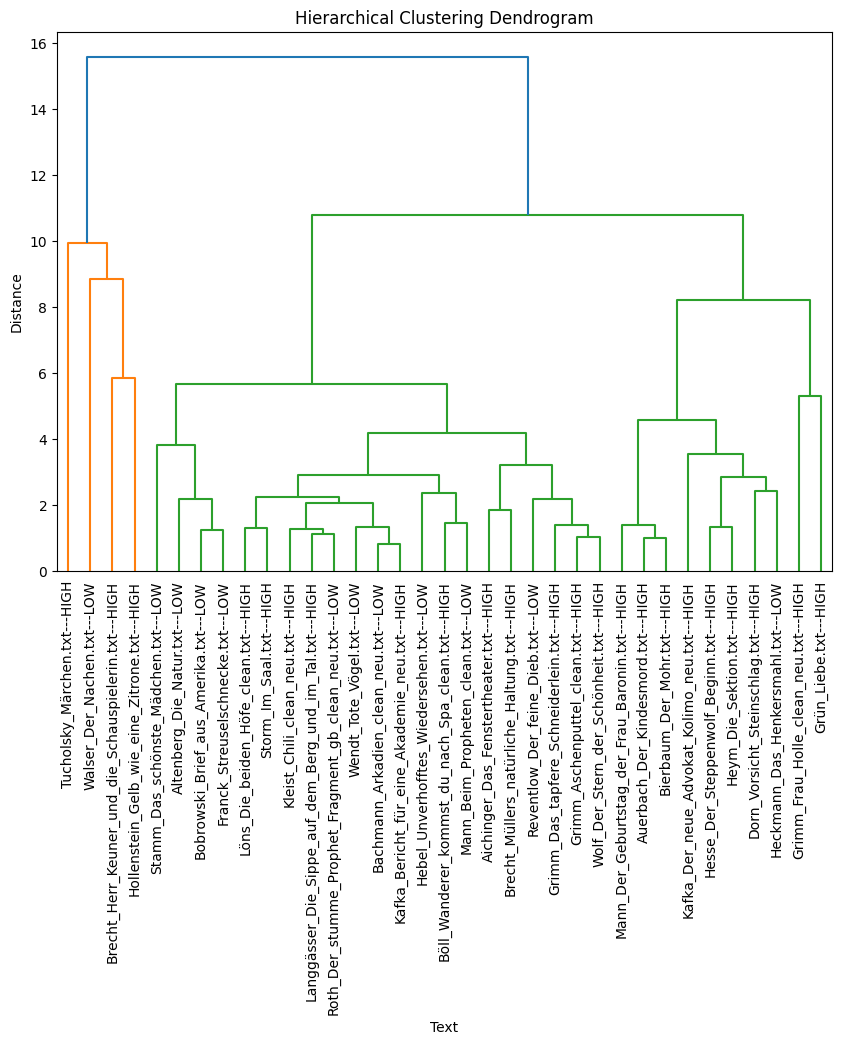

In [327]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Step 1: Drop the text column (assuming it's the first column)
text_labels = result_df.iloc[:, 0]  # Store the text labels (first column)
#features_df = result_df.drop(result_df.columns[0], axis=1)  # Drop the text column


# Step 2: Convert the feature columns into a NumPy array
features_array = features_df.values  # Convert to NumPy array

# Step 3: Perform hierarchical clustering using SciPy's linkage method
Z = linkage(features_array, method='ward')  # 'ward' is commonly used, but you can use 'single', 'complete', etc.

# Step 4: Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=text_labels.tolist(), leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Text")
plt.ylabel("Distance")
plt.show()


In [328]:
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

# Compute the cophenetic correlation coefficient
coph_corr, coph_dist = cophenet(Z, pdist(features_df.values))
print(f"Cophenetic Correlation Coefficient: {coph_corr}")

Cophenetic Correlation Coefficient: 0.8440926289358848


#Feature importance with random forest

In [329]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
num_clusters = 4
clusters = fcluster(Z, num_clusters, criterion='maxclust')
clusters

array([3, 3, 4, 3, 4, 3, 1, 3, 3, 4, 3, 3, 3, 4, 4, 3, 4, 4, 4, 1, 3, 4,
       3, 3, 3, 3, 4, 3, 3, 3, 3, 2, 1, 3, 3], dtype=int32)

In [330]:
from sklearn.ensemble import RandomForestClassifier

# Assuming you already have cluster labels (from hierarchical clustering or KMeans)
# 'clusters' is a list/array of cluster labels you already computed
#clusters = ...  # Your clustering labels (e.g., from AgglomerativeClustering)


# Step 1: Train a Random Forest classifier using the clusters as labels
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(features_df, clusters)

# Step 2: Get feature importances
importances = rf.feature_importances_

# Step 3: Map feature importances to column names
feature_importance = pd.Series(importances, index=features_df.columns).sort_values(ascending=False)

# Display feature importance
print("Feature importance according to Random Forest:")
print(feature_importance)


Feature importance according to Random Forest:
explicit_evaluations                             0.221117
narrator_evaluations                             0.206892
positive_evaluations                             0.161081
negative_evaluations                             0.106391
encoding_oppositions                             0.066257
overlapping_oppositions                          0.055829
character_evaluations                            0.048792
feature_oppositions                              0.039310
value_oppositions                                0.036563
implicit_evaluations                             0.030214
evaluative_difference_of_contrastive_entities    0.016979
evaluations_composition_level                    0.010575
dtype: float64


# PCA

In [331]:
features_df.head()

,narrator_evaluations,character_evaluations,evaluations_composition_level,value_oppositions,encoding_oppositions,feature_oppositions,positive_evaluations,negative_evaluations,overlapping_oppositions,explicit_evaluations,implicit_evaluations,evaluative_difference_of_contrastive_entities
0,-0.429764,-0.271990,0.349262,-0.545702,-0.188951,0.356973,-1.004811,0.489451,-0.066359,-0.747484,0.161741,0.229459
1,-1.660702,0.523324,-0.432224,-0.545702,1.028400,0.204885,-0.523086,-1.656750,-0.586013,-0.883960,-1.138784,-0.480949
2,0.222238,0.876398,-0.432224,-0.417335,-0.647047,-0.295411,0.350433,0.916464,-0.346047,0.852097,-0.040623,-0.031024
3,0.088918,-1.031464,-0.432224,-0.202369,0.054372,-0.677612,-0.226389,-0.970439,-0.586013,-0.266872,-0.588066,-0.480949
4,0.373354,0.958458,-0.169711,-0.545702,-0.100273,0.017452,0.222910,1.127250,-0.236895,1.264757,-0.389872,-0.300175


In [332]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

# Step 1: Perform PCA with two components for 2D visualization
pca_2d = PCA(n_components=2)
pca_result = pca_2d.fit_transform(features_df)

# Create a DataFrame for the PCA results, with columns 'PC1' and 'PC2'
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'], index=features_df.index)

# Add the 'Document_title' and 'implizite_Assertion_Category' columns from result_df to pca_df
pca_df['Document_title'] = result_df['Document_title']
pca_df['assertive_clarity_cat2'] = result_df['assertive_force_cat2']

# Step 2: Plot using Plotly with hover info and color by 'implizite_Assertion_Category'
fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='assertive_clarity_cat2',
    hover_data=['Document_title'],
    labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2'},
    title="PCA Plot with Document Titles and Categories"
)

# Step 3: Show the interactive plot
fig.show()


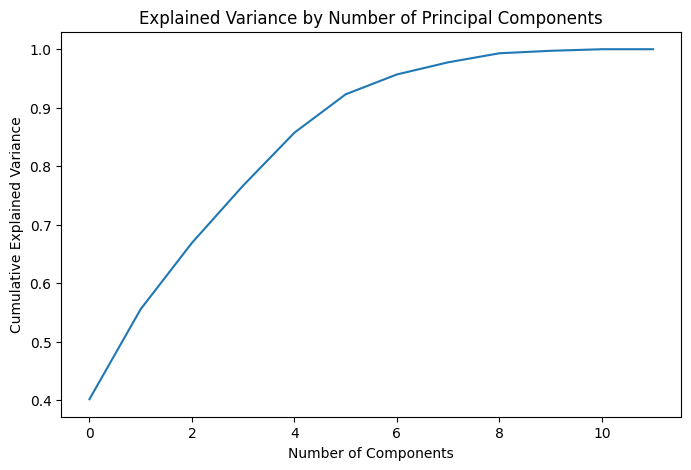

Feature importance for the first principal component:
positive_evaluations                             0.413393
explicit_evaluations                             0.399561
narrator_evaluations                             0.384460
encoding_oppositions                             0.348507
implicit_evaluations                             0.312188
negative_evaluations                             0.282885
overlapping_oppositions                          0.247755
character_evaluations                            0.211861
evaluative_difference_of_contrastive_entities    0.202972
evaluations_composition_level                    0.190498
value_oppositions                                0.145607
feature_oppositions                              0.133229
dtype: float64


In [333]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Drop the text column (assuming it's the first column)
#features_df = result_df.drop(result_df.columns[0], axis=1)

# Step 1: Perform PCA
pca = PCA()
pca.fit(features_df)

# Step 2: Get explained variance ratio for each principal component
explained_variance = pca.explained_variance_ratio_

# Step 3: Plot explained variance to visualize which components have most variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(explained_variance))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Number of Principal Components')
plt.show()

# Step 4: Get the loadings for each feature in the first principal component
loadings = pca.components_[0]

# Map loadings to feature names
feature_importance = pd.Series(loadings, index=features_df.columns)

# Sort by absolute value to get most important features
feature_importance = feature_importance.abs().sort_values(ascending=False)

# Display the most important features
print("Feature importance for the first principal component:")
print(feature_importance)


# TSNE

In [334]:
import pandas as pd
from sklearn.manifold import TSNE
import plotly.express as px

# Step 1: Perform t-SNE with two components for 2D visualization
# Perplexity should be less than the number of samples
perplexity_value = min(30, len(result_df) // 3)  # Set perplexity to a value lower than n_samples
tsne = TSNE(n_components=2, perplexity=perplexity_value, random_state=42)  # random_state for reproducibility
tsne_result = tsne.fit_transform(features_df)

# Create a DataFrame for the t-SNE results, with columns 'TSNE1' and 'TSNE2'
tsne_df = pd.DataFrame(tsne_result, columns=['TSNE1', 'TSNE2'], index=features_df.index)

# Add the 'Document_title' and 'implizite_Assertion_Category' columns from result_df to tsne_df
tsne_df['Document_title'] = result_df['Document_title']
tsne_df['assertive_clarity_cat2'] = result_df['assertive_clarity_cat2']

# Step 2: Plot using Plotly with hover info and color by 'implizite_Assertion_Category'
fig = px.scatter(
    tsne_df,
    x='TSNE1',
    y='TSNE2',
    color='assertive_clarity_cat2',
    hover_data=['Document_title'],
    labels={'TSNE1': 't-SNE Component 1', 'TSNE2': 't-SNE Component 2'},
    title="t-SNE Plot with Document Titles and Categories"
)

# Step 3: Show the interactive plot
fig.show()


In [335]:
#manuell exploren
result_df.reset_index(drop=True, inplace=True)
first_column = result_df.iloc[:, 0]
normalized_df_labels = pd.concat([first_column, normalized_df], axis=1)
normalized_df_labels.set_index(normalized_df_labels.columns[0], inplace=True)

In [336]:
normalized_df_labels["evaluative_difference_of_contrastive_entities"].sort_values(ascending=False)

,evaluative_difference_of_contrastive_entities
Document_title,
Hollenstein_Gelb_wie_eine_Zitrone.txt---HIGH,4.018299
Grimm_Frau_Holle_clean_neu.txt---HIGH,3.568374
Brecht_Müllers_natürliche_Haltung.txt---HIGH,0.682650
Brecht_Herr_Keuner_und_die_Schauspielerin.txt---HIGH,0.557339
Hebel_Unverhofftes_Wiedersehen.txt---LOW,0.557339
Löns_Die_beiden_Höfe_clean.txt---HIGH,0.290351
Kleist_Chili_clean_neu.txt---HIGH,0.251487
Aichinger_Das_Fenstertheater.txt---HIGH,0.229459
Dorn_Vorsicht_Steinschlag.txt---HIGH,0.105910


# Clustering Networks based on structural features

In [40]:
!pip install thefuzz[speedup]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 27.6 MB/s eta 0:00:00


In [376]:
import pandas as pd
import unicodedata

# Define normalization function for a single filename
def normalize_filename(filename):
    return unicodedata.normalize('NFC', filename)

from sklearn.preprocessing import RobustScaler

In [377]:
# Step 1: Import necessary libraries
import networkx as nx
import pandas as pd
import numpy as np
from google.colab import drive
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os

# Step 2: Mount Google Drive
drive.mount('/content/drive')

# Set the path to your GraphML files
#graphml_folder = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/complete_network_graphml_18Dec2024/'  # Change this to your folder path
graphml_folder = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/MoL_network_visualization_output_20250527/complete_network_graphml_27May2025/'  # Change this to your folder path


import networkx as nx

import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

#set.seed(12345)

# Function to compute single hub/authority score
def compute_deviation_score(scores):
    max_score = max(scores.values())
    deviations = [max_score - score for score in scores.values() if score != max_score]
    return sum(deviations)/len(scores.values())   # Sum of differences

def compute_network_properties(graph):
    G = graph

    # Target node
    target_node = "Namenloser Erzähler1"

    # Number of nodes
    num_nodes = graph.number_of_nodes()

    #indegrees variance
      # Get in-degrees of all nodes
    in_degrees = np.array([deg for _, deg in graph.in_degree()])

    if len(in_degrees) <= 1:
        return 0.0  # Single-node or empty graph has no disparity

    # Calculate variance of in-degrees
    indegrees_variance = np.var(in_degrees)
    normalized_indegrees_variance = indegrees_variance / num_nodes

    #outdegrees variance
      # Get out-degrees of all nodes
    out_degrees = np.array([deg for _, deg in graph.out_degree()])

    if len(out_degrees) <= 1:
        return 0

    # Calculate variance of out-degrees
    outdegrees_variance = np.var(out_degrees)
    normalized_outdegrees_variance = outdegrees_variance / num_nodes

    # starshape score
      # Compute out-degrees for all nodes
    out_degrees = dict(graph.out_degree())

    # Find the two nodes with the highest out-degrees
    sorted_degrees = sorted(out_degrees.values(), reverse=True)

    if len(sorted_degrees) < 2:  # Handle cases with only one node with out-degree
        return float('inf')  # Perfect star-like structure

    # Compute the starshape score
    highest = sorted_degrees[0]
    second_highest = sorted_degrees[1]
    third_highest = sorted_degrees[2] if len(sorted_degrees) > 1 else 0
    starshape = highest / (second_highest + third_highest) if second_highest > 0 else float('inf')

    # Calculate the number of modules using greedy modularity
    communities = list(greedy_modularity_communities(graph))
    num_modules = len(communities)

    # Count strongly connected subgraphs with more than one node
    number_strongly_components = sum(1 for c in nx.strongly_connected_components(graph) if len(c) > 1)

    # Count weakly connected subgraphs with more than one node
    number_weakly_components = sum(1 for c in nx.weakly_connected_components(graph) if len(c) > 1)

    # Triadic census
    census = nx.triadic_census(graph)
    #print(census)

    # Total number of triads (sum of all triads in the census)
    total_triads = sum(census.values())

    # narrator centrality
    if target_node in graph:
        # Calculate degree centrality for all nodes
        degree_centralities = nx.degree_centrality(graph)

        # Centrality of the target node
        target_centrality = degree_centralities[target_node]

        # Centrality of other nodes
        other_nodes = [node for node in graph if node != target_node]
        if other_nodes:
            average_other_centrality = sum(degree_centralities[node] for node in other_nodes) / len(other_nodes)
        else:
            average_other_centrality = 0  # Edge case: only one node in the graph

        # Calculate the relative narrator centrality
        narrator_centrality = target_centrality / average_other_centrality if average_other_centrality > 0 else float('inf')
    else:
        narrator_centrality = None
        target_centrality = None

    # Compute HITS scores
    h, a = nx.hits(graph)
    # Normalize scores to [0, 1]
    #max_h, max_a = max(h.values(), default=1), max(a.values(), default=1)
    #normalized_h = {node: score / max_h for node, score in h.items()}
    #normalized_a = {node: score / max_a for node, score in a.items()}

    # Function to compute single hub/authority score
    hub_score = compute_deviation_score(h)
    authority_score = compute_deviation_score(a)


    # Calculate in-degree and out-degree for all nodes
    in_degrees = dict(graph.in_degree())  # Includes weights (number of parallel edges)
    out_degrees = dict(graph.out_degree())

    # Find the node with the maximum in-degree
    max_in_degree_node = max(in_degrees, key=in_degrees.get)
    max_out_degree_node = max(out_degrees, key=out_degrees.get)

    # get values
    in_degree_max = in_degrees[max_in_degree_node]
    out_degree_max = out_degrees[max_out_degree_node]


    # Triadic census
    census = nx.triadic_census(G)
    # Total number of triads (sum of all triads in the census)
    total_triads = sum(census.values())


    return {
        #"narrator degree centrality": target_centrality,
        #"relative narrator degree centrality": narrator_centrality,
        #"number of modules": num_modules,
        "number of strongly connected components": number_strongly_components / num_nodes,
        "number of weakly connected components": number_weakly_components / num_nodes,
        #"total number of triads": total_triads / num_nodes,
        "hub score": hub_score,
        "authority score": authority_score,
        #"max in-degree node": max_in_degree_node,
        #"max out-degree node": max_out_degree_node,
        "in-degree_max": in_degree_max / num_nodes,
        "out-degree max": out_degree_max / num_nodes,
        #"starshape score": starshape,
        #"out-degree centrality": nx.out_degree_centrality(nx.Graph(graph)),
        "in-degree variance": normalized_indegrees_variance,
        "out-degree variance": normalized_outdegrees_variance,
        "reciprocity": nx.reciprocity(graph),
        "density": nx.density(graph),
        "transitivity": nx.transitivity(nx.Graph(G)),
        #"acyclical (DAG)": nx.is_directed_acyclic_graph(G),
        "003": census["003"] / num_nodes,
        "012": census["012"] / num_nodes,
        "102": census["102"] / num_nodes,
        "021D": census["021D"] / num_nodes,
        "021U": census["021U"] / num_nodes,
        "021C": census["021C"] / num_nodes,
        "111D": census["111D"] / num_nodes,
        "111U": census["111U"] / num_nodes,
        "030T": census["030T"] / num_nodes,
        "030C": census["030C"] / num_nodes,
        "201": census["201"] / num_nodes,
        "120D": census["120D"] / num_nodes, # intersting
        "120U": census["120U"] / num_nodes,
        "120C": census["120C"] / num_nodes,
        "210": census["210"] / num_nodes,
        "300": census["300"] / num_nodes
    }

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [378]:
# Step 4: Loop through each GraphML file, compute network properties, and store in DataFrame
network_data = []

for filename in os.listdir(graphml_folder):
    if filename.endswith(".graphml"):
        file_path = os.path.join(graphml_folder, filename)
        graph = nx.read_graphml(file_path, force_multigraph=True)

        # Compute network properties for the current graph
        properties = compute_network_properties(graph)
        #properties = compute_structural_features(graph)

        #print(properties)

        # Check if properties were collected and add the filename as the network identifier
        if properties:
            properties['Network'] = filename  # Add network identifier
            network_data.append(properties)
        else:
            print(f"Warning: No properties calculated for {filename}")
    else:
      print(f"Warning: Skipping non-GraphML file: {filename}")

# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(network_data)
print(network_data)
df.set_index('Network', inplace=True)

df_network_features = df.copy()

# Step 5.1: Check and replace any NaN or infinite values in the scaled data
#df_scaled.replace([np.inf, -np.inf], np.nan, inplace=True)  # Replace infinities with NaN
#df_scaled.fillna(0, inplace=True)  # Replace NaNs with 0 (or choose another strategy if needed)
#df.sort_values("hub score")

[{'number of strongly connected components': 0.14285714285714285, 'number of weakly connected components': 0.03571428571428571, 'hub score': 1.3879341753517964, 'authority score': 0.3136007632377306, 'in-degree_max': 0.17857142857142858, 'out-degree max': 0.7142857142857143, 'in-degree variance': np.float64(0.03680758017492712), 'out-degree variance': np.float64(0.56231778425656), 'reciprocity': 0.3, 'density': 0.05291005291005291, 'transitivity': 0.017857142857142856, '003': 96.03571428571429, '012': 10.142857142857142, '102': 4.892857142857143, '021D': 5.357142857142857, '021U': 0.0, '021C': 0.0, '111D': 0.21428571428571427, '111U': 0.21428571428571427, '030T': 0.0, '030C': 0.0, '201': 0.10714285714285714, '120D': 0.03571428571428571, '120U': 0.0, '120C': 0.0, '210': 0.0, '300': 0.0, 'Network': 'Heym_Die_Sektion.txt_complete_network.graphml'}, {'number of strongly connected components': 0.08536585365853659, 'number of weakly connected components': 0.024390243902439025, 'hub score': 0

In [379]:
# get categories from other df
df_network_features["file"] = df_network_features.index.astype(str).str.split("_complete_network").str[0]
df_network_features["file"] = df_network_features["file"].apply(normalize_filename)
#print(df["file"])
# select cols from result_df
df2 = result_df[['Document_title','assertive_clarity_cat2']]

##### rename #####
df2["file"] = df2['Document_title']
df2["file"] = df2["file"].apply(lambda x: x.split("---")[0] if "---" in x else x)
#df2["file"] = df2['Document_title'].str.split(".txt").str[0].str.split("_clean").str[0].apply(normalize_filename)
#df2["file"] = df2["file"].apply(lambda x: x.split("---")[0] if "---" in x else x)
#df_scaled["file"] = df_scaled["file"].apply(lambda x: x.split(".txt")[0] if ".txt" in x else x)


print(len(df_network_features))
print(len(df2))
merged_df = pd.merge(df_network_features, df2, on='file'.split("---")[0], how='inner')
print(len(merged_df))
merged_df.head()

35
35
35


,number of strongly connected components,number of weakly connected components,hub score,authority score,in-degree_max,out-degree max,in-degree variance,out-degree variance,reciprocity,density,transitivity,003,012,102,021D,021U,021C,111D,111U,030T,030C,201,120D,120U,120C,210,300,file,Document_title,assertive_clarity_cat2
0,0.142857,0.035714,1.387934,0.313601,0.178571,0.714286,0.036808,0.562318,0.300000,0.052910,0.017857,96.035714,10.142857,4.892857,5.357143,0.000000,0.000000,0.214286,0.214286,0.000000,0.0,0.107143,0.035714,0.000000,0.0,0.0,0.000000,Heym_Die_Sektion.txt,Heym_Die_Sektion.txt---HIGH,LOW
1,0.085366,0.024390,0.668066,1.446091,0.219512,0.951220,0.080942,0.939657,0.161074,0.022433,0.032903,1006.012195,47.231707,8.268293,17.207317,0.182927,0.475610,0.121951,0.268293,0.134146,0.0,0.024390,0.048780,0.024390,0.0,0.0,0.000000,Kleist_Chili_clean_neu.txt,Kleist_Chili_clean_neu.txt---HIGH,HIGH
2,0.076923,0.076923,0.393302,0.403993,1.307692,1.384615,1.533000,2.160218,0.352941,0.217949,0.000000,15.461538,2.230769,0.692308,3.461538,0.000000,0.000000,0.076923,0.076923,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,Dorn_Vorsicht_Steinschlag.txt,Dorn_Vorsicht_Steinschlag.txt---HIGH,LOW
3,0.333333,0.250000,0.449922,0.465778,0.250000,0.416667,0.048611,0.145833,0.666667,0.136364,0.450000,9.750000,3.500000,3.916667,0.250000,0.000000,0.000000,0.166667,0.500000,0.000000,0.0,0.000000,0.083333,0.083333,0.0,0.0,0.083333,Bobrowski_Brief_aus_Amerika.txt,Bobrowski_Brief_aus_Amerika.txt---LOW,LOW
4,0.130435,0.043478,1.228965,0.291097,0.478261,1.260870,0.468316,2.003288,0.310345,0.114625,0.093023,58.695652,11.260870,1.782609,3.347826,0.086957,0.826087,0.217391,0.608696,0.043478,0.0,0.000000,0.043478,0.086957,0.0,0.0,0.000000,Brecht_Müllers_natürliche_Haltung.txt,Brecht_Müllers_natürliche_Haltung.txt---HIGH,LOW


In [380]:
# Get the common values
common_files = set(df_network_features['file']) & set(df2['file'])

# Get files in df_scaled that are not in df2
not_found_files = df_network_features[~df_network_features['file'].isin(df2['file'])]['file']

# Print them
print("Files not found in df2:")
print(not_found_files.tolist())


Files not found in df2:
[]


## kmeans

In [381]:
# Step 1: Select only numeric columns and make a copy
merged_df_num = merged_df.select_dtypes(include=[np.number]).copy()

For n_clusters = 2, the silhouette score is 0.9377
For n_clusters = 3, the silhouette score is 0.7930
For n_clusters = 4, the silhouette score is 0.7498
For n_clusters = 5, the silhouette score is 0.7409
For n_clusters = 6, the silhouette score is 0.6739
For n_clusters = 7, the silhouette score is 0.6358
For n_clusters = 8, the silhouette score is 0.5993
For n_clusters = 9, the silhouette score is 0.5608
For n_clusters = 10, the silhouette score is 0.5203


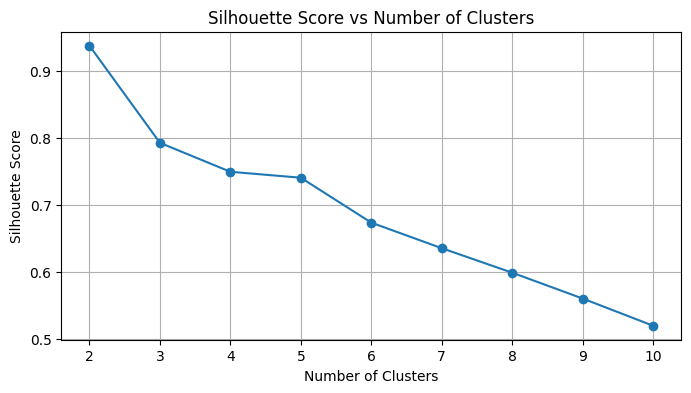

In [382]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Assuming merged_df_num is your numerical DataFrame and already scaled (important!)
X = merged_df_num

# Optional: Scale if not already scaled
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X) # already done above
X_scaled = X

# Try different values of k
range_n_clusters = range(2, 11)
silhouette_scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)
    print(f"For n_clusters = {k}, the silhouette score is {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(8, 4))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()


In [383]:
# Cluster (adjust n_clusters as needed)
n_clusters = 2  # Example - choose based on your data
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Results
results = pd.DataFrame({
    'network': list(merged_df["file"]),
    'cluster': clusters
})
results

,network,cluster
0,Heym_Die_Sektion.txt,0
1,Kleist_Chili_clean_neu.txt,0
2,Dorn_Vorsicht_Steinschlag.txt,0
3,Bobrowski_Brief_aus_Amerika.txt,0
4,Brecht_Müllers_natürliche_Haltung.txt,0
5,Stamm_Das_schönste_Mädchen.txt,0
6,Heckmann_Das_Henkersmahl.txt,0
7,Böll_Wanderer_kommst_du_nach_Spa_clean.txt,0
8,Franck_Streuselschnecke.txt,0
9,Brecht_Herr_Keuner_und_die_Schauspielerin.txt,0


## evaluation with F-score

In [384]:
# get labels

# Step 1: Clean both indexes by stripping '_split_network.graphml'
#df1.index = df1.index.astype(str).str.split('.txt').str[0]
df_assertion['file'] = df_assertion['Document_title'].astype(str).str.split('.txt').str[0]

# Step 2: Create a mapping from cleaned Document_title to assertive_clarity_cat
mapping_series = df_assertion.set_index('file')['assertive_clarity_cat']
#mapping_series = df_assertion.set_index('Document_title')['implicit_assertion_cat']
#mapping_series = df_assertion.set_index('Document_title')['assertive_clarity_cat']

"""
# Step 3: Create new index by combining assertive_clarity_cat + first 15 chars of filename
new_index = []
for fname in df1.index:
    cat = mapping_series.get(fname, "UNKNOWN")  # fallback if not found
    new_name = f"{cat}_{fname[:15]}"
    new_index.append(new_name)

# Step 4: Assign new index to average_df
df1.index = new_index
"""

'\n# Step 3: Create new index by combining assertive_clarity_cat + first 15 chars of filename\nnew_index = []\nfor fname in df1.index:\n    cat = mapping_series.get(fname, "UNKNOWN")  # fallback if not found\n    new_name = f"{cat}_{fname[:15]}"\n    new_index.append(new_name)\n\n# Step 4: Assign new index to average_df\ndf1.index = new_index\n'

In [385]:
true_labels_df = mapping_series
true_labels_df

,assertive_clarity_cat
file,
Aichinger_Das_Fenstertheater,HIGH
Altenberg_Die_Natur,LOW
Auerbach_Der_Kindesmord,HIGH
Bachmann_Arkadien_clean_neu,LOW
Bierbaum_Der_Mohr,HIGH
Bobrowski_Brief_aus_Amerika,LOW
Böll_Wanderer_kommst_du_nach_Spa_clean,HIGH
Brecht_Herr_Keuner_und_die_Schauspielerin,HIGH
Brecht_Müllers_natürliche_Haltung,LOW



Per-class metrics:
- LOW (0): Precision = 0.529, Recall = 1.000, F1 = 0.692
- HIGH (1):    Precision = 1.000, Recall = 0.059, F1 = 0.111

Macro F1:    0.402
Weighted F1: 0.410

Classification Report:
              precision    recall  f1-score   support

         LOW       0.53      1.00      0.69        18
        HIGH       1.00      0.06      0.11        17

    accuracy                           0.54        35
   macro avg       0.76      0.53      0.40        35
weighted avg       0.76      0.54      0.41        35


Missing networks analysis:
- In true labels but not in clustering results: 0
- In clustering results but not in true labels: 0


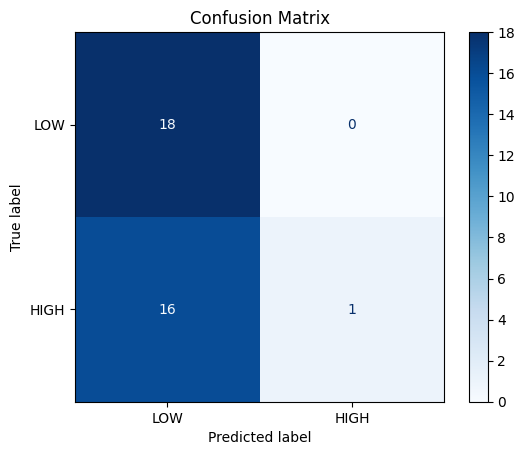

In [386]:
import pandas as pd

import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,  # <-- Add this import
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Assuming:
# - results_df (from clustering) has columns: 'network' and 'cluster'
# - true_labels_df has index 'Document_title' and column 'assertive_force_cat'

# 1. Prepare the dataframes
# Create base_name columns in both dataframes
results_df = results.copy()  # Make sure we're working with a DataFrame
results_df['base_name'] = results_df['network'].apply(lambda x: x.split('.txt')[0] if '.txt' in x else x)

# Reset index on true_labels_df to make Document_title a column
true_labels_df = true_labels_df.reset_index()
true_labels_df['base_name'] = true_labels_df['file'].apply(lambda x: x.split('.txt')[0] if '.txt' in x else x)

# 2. Merge the dataframes
merged = pd.merge(results_df, true_labels_df,
                 on='base_name',
                 how='inner')

if len(merged) == 0:
    raise ValueError("No matching networks found between clustering results and true labels")

# 3. Label clusters by majority vote
cluster_labels = {}
for cluster in merged['cluster'].unique():
    cluster_df = merged[merged['cluster'] == cluster]
    majority = cluster_df['assertive_clarity_cat'].mode()[0]  # Get most frequent label
    cluster_labels[cluster] = majority

# 4. Assign predicted labels
merged['predicted_label'] = merged['cluster'].map(cluster_labels)

# 5. Calculate extended metrics
# Convert labels to binary (if not already done)
label_map = {'HIGH': 1, 'LOW': 0}
merged['true_binary'] = merged['assertive_clarity_cat'].map(label_map)
merged['predicted_binary'] = merged['predicted_label'].map(label_map)

# Individual class precision/recall/F1
precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
    merged['true_binary'],
    merged['predicted_binary'],
    labels=[0, 1]  # LOW (0), HIGH (1)
)

# Macro F1 (unweighted mean across classes)
macro_f1 = f1_score(
    merged['true_binary'],
    merged['predicted_binary'],
    average='macro'
)

# Weighted F1 (weighted by support)
weighted_f1 = f1_score(
    merged['true_binary'],
    merged['predicted_binary'],
    average='weighted'
)

# Print results
print("\nPer-class metrics:")
print(f"- LOW (0): Precision = {precision_per_class[0]:.3f}, Recall = {recall_per_class[0]:.3f}, F1 = {f1_per_class[0]:.3f}")
print(f"- HIGH (1):    Precision = {precision_per_class[1]:.3f}, Recall = {recall_per_class[1]:.3f}, F1 = {f1_per_class[1]:.3f}")
print(f"\nMacro F1:    {macro_f1:.3f}")
print(f"Weighted F1: {weighted_f1:.3f}")

# Alternative: Full classification report (includes all metrics)
print("\nClassification Report:")
print(classification_report(
    merged['true_binary'],
    merged['predicted_binary'],
    target_names=['LOW', 'HIGH']
))

# 6. Show missing networks (optional)
missing_in_results = set(true_labels_df['base_name']) - set(results_df['base_name'])
missing_in_labels = set(results_df['base_name']) - set(true_labels_df['base_name'])

print("\nMissing networks analysis:")
print(f"- In true labels but not in clustering results: {len(missing_in_results)}")
if missing_in_results:
    print("  Examples:", list(missing_in_results)[:3])
print(f"- In clustering results but not in true labels: {len(missing_in_labels)}")
if missing_in_labels:
    print("  Examples:", list(missing_in_labels)[:3])

# 7. Confusion matrix (optional)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(merged['true_binary'], merged['predicted_binary'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=['LOW', 'HIGH'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [387]:
# Generate the classification report as a string
report_str = classification_report(
    merged['true_binary'],
    merged['predicted_binary'],
    target_names=['LOW', 'HIGH'],
    output_dict=False  # This returns a string
)

# Convert the string report to a dictionary (which pandas can easily convert to DataFrame)
report_dict = classification_report(
    merged['true_binary'],
    merged['predicted_binary'],
    target_names=['LOW', 'HIGH'],
    output_dict=True  # This returns a dictionary
)

# Convert the dictionary to a DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Save to Excel
report_df.to_excel("portrait_classification_report_force.xlsx")

print("Classification report saved to 'classification_report.xlsx'")

Classification report saved to 'classification_report.xlsx'


In [388]:
results_df

,network,cluster,base_name
0,Heym_Die_Sektion.txt,0,Heym_Die_Sektion
1,Kleist_Chili_clean_neu.txt,0,Kleist_Chili_clean_neu
2,Dorn_Vorsicht_Steinschlag.txt,0,Dorn_Vorsicht_Steinschlag
3,Bobrowski_Brief_aus_Amerika.txt,0,Bobrowski_Brief_aus_Amerika
4,Brecht_Müllers_natürliche_Haltung.txt,0,Brecht_Müllers_natürliche_Haltung
5,Stamm_Das_schönste_Mädchen.txt,0,Stamm_Das_schönste_Mädchen
6,Heckmann_Das_Henkersmahl.txt,0,Heckmann_Das_Henkersmahl
7,Böll_Wanderer_kommst_du_nach_Spa_clean.txt,0,Böll_Wanderer_kommst_du_nach_Spa_clean
8,Franck_Streuselschnecke.txt,0,Franck_Streuselschnecke
9,Brecht_Herr_Keuner_und_die_Schauspielerin.txt,0,Brecht_Herr_Keuner_und_die_Schauspielerin


In [389]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(merged['assertive_clarity_cat'], merged['cluster'])
#ari = adjusted_rand_score(merged['assertive_clarity_cat'], merged['cluster'])

print(f"Adjusted Rand Index: {ari:.3f}")
# Interpretation: 1=perfect match, 0=random, negative=worse than random

Adjusted Rand Index: 0.003


In [390]:
merged

,network,cluster,base_name,file,assertive_clarity_cat,predicted_label,true_binary,predicted_binary
0,Heym_Die_Sektion.txt,0,Heym_Die_Sektion,Heym_Die_Sektion,LOW,LOW,0,0
1,Kleist_Chili_clean_neu.txt,0,Kleist_Chili_clean_neu,Kleist_Chili_clean_neu,HIGH,LOW,1,0
2,Dorn_Vorsicht_Steinschlag.txt,0,Dorn_Vorsicht_Steinschlag,Dorn_Vorsicht_Steinschlag,LOW,LOW,0,0
3,Bobrowski_Brief_aus_Amerika.txt,0,Bobrowski_Brief_aus_Amerika,Bobrowski_Brief_aus_Amerika,LOW,LOW,0,0
4,Brecht_Müllers_natürliche_Haltung.txt,0,Brecht_Müllers_natürliche_Haltung,Brecht_Müllers_natürliche_Haltung,LOW,LOW,0,0
5,Stamm_Das_schönste_Mädchen.txt,0,Stamm_Das_schönste_Mädchen,Stamm_Das_schönste_Mädchen,LOW,LOW,0,0
6,Heckmann_Das_Henkersmahl.txt,0,Heckmann_Das_Henkersmahl,Heckmann_Das_Henkersmahl,LOW,LOW,0,0
7,Böll_Wanderer_kommst_du_nach_Spa_clean.txt,0,Böll_Wanderer_kommst_du_nach_Spa_clean,Böll_Wanderer_kommst_du_nach_Spa_clean,HIGH,LOW,1,0
8,Franck_Streuselschnecke.txt,0,Franck_Streuselschnecke,Franck_Streuselschnecke,LOW,LOW,0,0
9,Brecht_Herr_Keuner_und_die_Schauspielerin.txt,0,Brecht_Herr_Keuner_und_die_Schauspielerin,Brecht_Herr_Keuner_und_die_Schauspielerin,HIGH,LOW,1,0


In [391]:
# Count predicted labels per cluster
predicted_counts = merged.groupby('cluster')['predicted_label'].value_counts().unstack(fill_value=0)

print("Predicted counts per cluster:")
print(predicted_counts)

Predicted counts per cluster:
predicted_label  HIGH  LOW
cluster                   
0                   0   34
1                   1    0


In [392]:
# Count true labels per cluster
true_label_counts = merged.groupby('cluster')['true_binary'].value_counts().unstack(fill_value=0)

print("true label counts per cluster (0 = LOW, 1 = HIGH):")
print(true_label_counts)

true label counts per cluster (0 = LOW, 1 = HIGH):
true_binary   0   1
cluster            
0            18  16
1             0   1


In [393]:
# Create a new column indicating correct/incorrect classification
merged['correct'] = merged['true_binary'] == merged['predicted_binary']

# Initialize dictionaries to store results
cluster_results = {
    0: {'correct': [], 'incorrect': []},
    1: {'correct': [], 'incorrect': []},
    2: {'correct': [], 'incorrect': []}
}

# Iterate through each row and classify
for _, row in merged.iterrows():
    cluster = row['cluster']
    network = row['network']

    if row['correct']:
        cluster_results[cluster]['correct'].append(network)
    else:
        cluster_results[cluster]['incorrect'].append(network)

# Print results
for cluster in sorted(cluster_results.keys()):
    print(f"\nCluster {cluster}:")
    print(f"Correctly classified ({len(cluster_results[cluster]['correct'])}):")
    print(cluster_results[cluster]['correct'])

    print(f"\nIncorrectly classified ({len(cluster_results[cluster]['incorrect'])}):")
    print(cluster_results[cluster]['incorrect'])


Cluster 0:
Correctly classified (18):
['Heym_Die_Sektion.txt', 'Dorn_Vorsicht_Steinschlag.txt', 'Bobrowski_Brief_aus_Amerika.txt', 'Brecht_Müllers_natürliche_Haltung.txt', 'Stamm_Das_schönste_Mädchen.txt', 'Heckmann_Das_Henkersmahl.txt', 'Franck_Streuselschnecke.txt', 'Hebel_Unverhofftes_Wiedersehen.txt', 'Mann_Beim_Propheten_clean.txt', 'Reventlow_Der_feine_Dieb.txt', 'Bachmann_Arkadien_clean_neu.txt', 'Roth_Der_stumme_Prophet_Fragment_gb_clean_neu.txt', 'Wendt_Tote_Vögel.txt', 'Langgässer_Die_Sippe_auf_dem_Berg_und_im_Tal.txt', 'Mann_Der_Geburtstag_der_Frau_Baronin.txt', 'Altenberg_Die_Natur.txt', 'Kafka_Bericht_für_eine_Akademie_neu.txt', 'Walser_Der_Nachen.txt']

Incorrectly classified (16):
['Kleist_Chili_clean_neu.txt', 'Böll_Wanderer_kommst_du_nach_Spa_clean.txt', 'Brecht_Herr_Keuner_und_die_Schauspielerin.txt', 'Storm_Im_Saal.txt', 'Bierbaum_Der_Mohr.txt', 'Grimm_Frau_Holle_clean_neu.txt', 'Tucholsky_Märchen.txt', 'Grimm_Das_tapfere_Schneiderlein.txt', 'Wolf_Der_Stern_der_Schö

# Clustering based on network features and annotation features

In [406]:
# Adding the 'Document_title' column from result_df as a new column 'file' in normalized_df
df_annotation_features['file'] = result_df['Document_title']
df_annotation_features['Document_title'] = result_df['Document_title']
df_annotation_features['file'] = df_annotation_features['file'].str.split("---").str[0]
df_annotation_features.head()

,narrator_evaluations,character_evaluations,evaluations_composition_level,value_oppositions,encoding_oppositions,feature_oppositions,positive_evaluations,negative_evaluations,overlapping_oppositions,explicit_evaluations,implicit_evaluations,evaluative_difference_of_contrastive_entities,file,Document_title
0,0.018661,0.005488,0.001098,0.000000,0.002195,0.004391,0.006586,0.019759,0.002195,0.016465,0.007684,0.052632,Aichinger_Das_Fenstertheater.txt,Aichinger_Das_Fenstertheater.txt---HIGH
1,0.003745,0.011236,0.000000,0.000000,0.007491,0.003745,0.011236,0.001873,0.000000,0.014981,0.000000,0.000000,Altenberg_Die_Natur.txt,Altenberg_Die_Natur.txt---LOW
2,0.026561,0.013788,0.000000,0.000406,0.000203,0.001622,0.019667,0.023317,0.001014,0.033861,0.006488,0.033333,Auerbach_Der_Kindesmord.txt,Auerbach_Der_Kindesmord.txt---HIGH
3,0.024946,0.000000,0.000000,0.001085,0.003254,0.000000,0.014100,0.007592,0.000000,0.021692,0.003254,0.000000,Bachmann_Arkadien_clean_neu.txt,Bachmann_Arkadien_clean_neu.txt---LOW
4,0.028392,0.014381,0.000369,0.000000,0.002581,0.002950,0.018437,0.025074,0.001475,0.038348,0.004425,0.013393,Bierbaum_Der_Mohr.txt,Bierbaum_Der_Mohr.txt---HIGH


In [407]:
merged_df = pd.merge(df_scaled, normalized_df, on='file', how='inner')
non_matching_rows = df_scaled[~df_scaled['file'].isin(merged_df['file'])]
print(non_matching_rows)
len(merged_df)

Empty DataFrame
Columns: [number of strongly connected components, number of weakly connected components, hub score, authority score, in-degree_max, out-degree max, in-degree variance, out-degree variance, reciprocity, density, transitivity, 003, 012, 102, 021D, 021U, 021C, 111D, 111U, 030T, 030C, 201, 120D, 120U, 120C, 210, 300, file]
Index: []


35

In [408]:
merged_df.head()

,number of strongly connected components,number of weakly connected components,hub score,authority score,in-degree_max,out-degree max,in-degree variance,out-degree variance,reciprocity,density,transitivity,003,012,102,021D,021U,021C,111D,111U,030T,030C,201,120D,120U,120C,210,300,file,narrator_evaluations,character_evaluations,evaluations_composition_level,value_oppositions,encoding_oppositions,feature_oppositions,positive_evaluations,negative_evaluations,overlapping_oppositions,explicit_evaluations,implicit_evaluations,evaluative_difference_of_contrastive_entities,Document_title
0,-0.035996,-0.795208,-0.075470,-0.284881,-0.828506,-0.710983,-0.590482,-0.690724,-0.067416,-0.575762,-0.716652,-0.236579,-0.109951,0.009982,-0.216358,-0.619541,-0.718376,0.449996,-0.261369,-0.659230,0.0,0.254919,-0.529627,-0.392808,0.0,-0.33831,-0.259007,Heym_Die_Sektion.txt,1.221269,-1.031464,-0.432224,-0.123631,0.532447,-0.363443,0.799289,1.158399,-0.586013,0.803621,-0.236096,-0.480949,Heym_Die_Sektion.txt---HIGH
1,-0.787565,-0.915874,-0.191734,-0.110491,-0.740056,-0.128091,-0.533952,-0.262552,-0.936025,-0.778424,-0.614478,0.338719,2.733064,0.509504,0.592585,0.411258,0.538202,-0.213859,-0.220981,1.602384,0.0,-0.448755,-0.342466,0.495513,0.0,-0.33831,-0.259007,Kleist_Chili_clean_neu.txt,-0.449250,-0.032895,-0.432224,-0.108273,-0.552468,-0.605256,-0.685015,0.108315,-0.404298,-0.101396,-0.774964,0.251487,Kleist_Chili_clean_neu.txt---HIGH
2,-0.897935,-0.356099,-0.236111,-0.270962,1.610893,0.938126,1.325917,1.122433,0.263588,0.521692,-0.837916,-0.287519,-0.716445,-0.611646,-0.345760,-0.619541,-0.718376,-0.537597,-0.364094,-0.659230,0.0,-0.656154,-1.041200,-0.392808,0.0,-0.33831,-0.259007,Dorn_Vorsicht_Steinschlag.txt,1.547002,-0.638350,-0.432224,0.353596,-0.367104,0.661176,0.373110,1.186580,1.095112,1.003903,0.544140,0.105910,Dorn_Vorsicht_Steinschlag.txt---HIGH
3,2.454050,1.488160,-0.226966,-0.261448,-0.674189,-1.443170,-0.575364,-1.163314,2.225094,-0.020823,2.217930,-0.291130,-0.619153,-0.134482,-0.564993,-0.619541,-0.718376,0.107631,-0.047702,-0.659230,0.0,-0.656154,0.152470,2.642290,0.0,-0.33831,3.393252,Bobrowski_Brief_aus_Amerika.txt,-1.570144,-0.026311,-0.432224,-0.545702,-0.693660,0.748700,-0.809169,-1.590916,-0.586013,-1.482290,-0.524060,-0.480949,Bobrowski_Brief_aus_Amerika.txt---LOW
4,-0.198390,-0.712478,-0.101145,-0.288346,-0.181045,0.633693,-0.037784,0.944362,-0.002737,-0.165381,-0.206217,-0.260186,-0.024250,-0.450295,-0.353522,-0.129538,1.464175,0.472324,0.033585,0.073783,0.0,-0.656154,-0.418415,2.774251,0.0,-0.33831,-0.259007,Brecht_Müllers_natürliche_Haltung.txt,-1.245592,0.763572,-0.160597,-0.424926,-0.518234,-0.497813,-1.410456,0.682328,-0.315083,-0.823121,-0.105566,0.682650,Brecht_Müllers_natürliche_Haltung.txt---HIGH


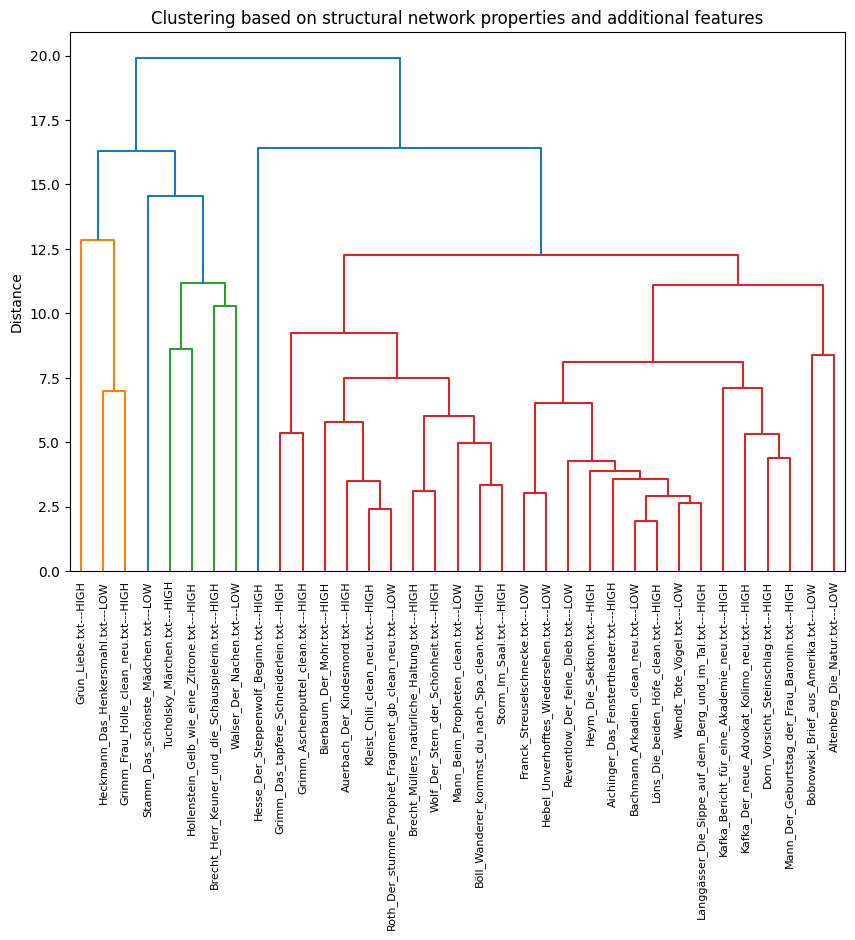

In [409]:
# Step 1: Select only numeric columns and make a copy
merged_df_num = merged_df.select_dtypes(include=[np.number]).copy()

# Step 2: Replace infinities with NaN, then fill NaNs with 0
merged_df_num.replace([np.inf, -np.inf], np.nan, inplace=True)
merged_df_num.fillna(0, inplace=True)

# Step 3: Extract the labels for the dendrogram
file_labels = merged_df["Document_title"].tolist()

# Step 4: Perform Hierarchical Clustering
linkage_matrix = linkage(merged_df_num, method='ward')

# Step 5: Plot the Dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix, labels=file_labels, leaf_rotation=90)
plt.title("Clustering based on structural network properties and additional features")
#plt.xlabel("Networks")
plt.ylabel("Distance")
plt.show()



In [410]:
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

# Compute the cophenetic correlation coefficient
coph_corr, coph_dist = cophenet(linkage_matrix, pdist(merged_df_num))
print(f"Cophenetic Correlation Coefficient: {coph_corr}")

Cophenetic Correlation Coefficient: 0.7959033612391232


# Feature selection

In [411]:
# Select only the necessary columns from df_assertion
df_assertion_subset = df_assertion[['Document_title', 'assertive_force_mean', 'assertive_clarity_mean']]
merged_df["Document_title_with_cat"] = merged_df["Document_title"]
merged_df['Document_title'] = merged_df['file']

# Merge with merged_df on the 'Document_title' column
anova_df = merged_df.merge(df_assertion_subset, on='Document_title', how='left')

# result_df now contains the merged DataFrame
anova_df.head()

,number of strongly connected components,number of weakly connected components,hub score,authority score,in-degree_max,out-degree max,in-degree variance,out-degree variance,reciprocity,density,transitivity,003,012,102,021D,021U,021C,111D,111U,030T,030C,201,120D,120U,120C,210,300,file,narrator_evaluations,character_evaluations,evaluations_composition_level,value_oppositions,encoding_oppositions,feature_oppositions,positive_evaluations,negative_evaluations,overlapping_oppositions,explicit_evaluations,implicit_evaluations,evaluative_difference_of_contrastive_entities,Document_title,Document_title_with_cat,assertive_force_mean,assertive_clarity_mean
0,-0.035996,-0.795208,-0.075470,-0.284881,-0.828506,-0.710983,-0.590482,-0.690724,-0.067416,-0.575762,-0.716652,-0.236579,-0.109951,0.009982,-0.216358,-0.619541,-0.718376,0.449996,-0.261369,-0.659230,0.0,0.254919,-0.529627,-0.392808,0.0,-0.33831,-0.259007,Heym_Die_Sektion.txt,1.221269,-1.031464,-0.432224,-0.123631,0.532447,-0.363443,0.799289,1.158399,-0.586013,0.803621,-0.236096,-0.480949,Heym_Die_Sektion.txt,Heym_Die_Sektion.txt---HIGH,6.333333,4.0
1,-0.787565,-0.915874,-0.191734,-0.110491,-0.740056,-0.128091,-0.533952,-0.262552,-0.936025,-0.778424,-0.614478,0.338719,2.733064,0.509504,0.592585,0.411258,0.538202,-0.213859,-0.220981,1.602384,0.0,-0.448755,-0.342466,0.495513,0.0,-0.33831,-0.259007,Kleist_Chili_clean_neu.txt,-0.449250,-0.032895,-0.432224,-0.108273,-0.552468,-0.605256,-0.685015,0.108315,-0.404298,-0.101396,-0.774964,0.251487,Kleist_Chili_clean_neu.txt,Kleist_Chili_clean_neu.txt---HIGH,7.0,7.0
2,-0.897935,-0.356099,-0.236111,-0.270962,1.610893,0.938126,1.325917,1.122433,0.263588,0.521692,-0.837916,-0.287519,-0.716445,-0.611646,-0.345760,-0.619541,-0.718376,-0.537597,-0.364094,-0.659230,0.0,-0.656154,-1.041200,-0.392808,0.0,-0.33831,-0.259007,Dorn_Vorsicht_Steinschlag.txt,1.547002,-0.638350,-0.432224,0.353596,-0.367104,0.661176,0.373110,1.186580,1.095112,1.003903,0.544140,0.105910,Dorn_Vorsicht_Steinschlag.txt,Dorn_Vorsicht_Steinschlag.txt---HIGH,6.0,4.333333
3,2.454050,1.488160,-0.226966,-0.261448,-0.674189,-1.443170,-0.575364,-1.163314,2.225094,-0.020823,2.217930,-0.291130,-0.619153,-0.134482,-0.564993,-0.619541,-0.718376,0.107631,-0.047702,-0.659230,0.0,-0.656154,0.152470,2.642290,0.0,-0.33831,3.393252,Bobrowski_Brief_aus_Amerika.txt,-1.570144,-0.026311,-0.432224,-0.545702,-0.693660,0.748700,-0.809169,-1.590916,-0.586013,-1.482290,-0.524060,-0.480949,Bobrowski_Brief_aus_Amerika.txt,Bobrowski_Brief_aus_Amerika.txt---LOW,4.0,3.666667
4,-0.198390,-0.712478,-0.101145,-0.288346,-0.181045,0.633693,-0.037784,0.944362,-0.002737,-0.165381,-0.206217,-0.260186,-0.024250,-0.450295,-0.353522,-0.129538,1.464175,0.472324,0.033585,0.073783,0.0,-0.656154,-0.418415,2.774251,0.0,-0.33831,-0.259007,Brecht_Müllers_natürliche_Haltung.txt,-1.245592,0.763572,-0.160597,-0.424926,-0.518234,-0.497813,-1.410456,0.682328,-0.315083,-0.823121,-0.105566,0.682650,Brecht_Müllers_natürliche_Haltung.txt,Brecht_Müllers_natürliche_Haltung.txt---HIGH,7.0,4.666667


## ANOVA (dependent metrical)

In [412]:
import pandas as pd
from sklearn.feature_selection import f_regression

# Assume anova_df is your normalized DataFrame with features and dependent variable
# Dependent variable
y = anova_df['assertive_clarity_mean']
#y = anova_df['assertive_clarity_mean']
y = pd.to_numeric(y, errors='coerce')

# Independent variables (all columns except the dependent variable)
X = anova_df.drop(columns=['assertive_force_mean', "assertive_clarity_mean", "file",	"Document_title", "Document_title_with_cat"])

# Perform ANOVA F-test
F_values, p_values = f_regression(X, y)

# Create a DataFrame for better visualization of results
anova_results = pd.DataFrame({
    'Feature': X.columns,
    'F_statistic': F_values,
    'p_value': p_values
})

# Sort features by F-statistic (descending order)
anova_results = anova_results.sort_values(by='F_statistic', ascending=False)

# Display the results
print(anova_results)

# Select significant features (e.g., p-value < 0.05)
significant_features = anova_results[anova_results['p_value'] < 0.05]['Feature']
print("Significant Features:", significant_features.tolist())


                                          Feature  F_statistic   p_value
22                                           120D     6.587061  0.014996
32                            feature_oppositions     5.970022  0.020067
16                                           021C     5.314656  0.027573
38  evaluative_difference_of_contrastive_entities     5.136731  0.030106
1           number of weakly connected components     5.083334  0.030915
8                                     reciprocity     4.469877  0.042139
15                                           021U     4.404816  0.043571
37                           implicit_evaluations     4.355769  0.044686
2                                       hub score     4.124898  0.050376
34                           negative_evaluations     3.290040  0.078804
5                                  out-degree max     2.665557  0.112049
3                                 authority score     2.523795  0.121677
12                                            012  

## Lasso Regression

Selected Features:
                                           Feature  Coefficient
16                                           021C     0.655276
38  evaluative_difference_of_contrastive_entities     0.566905
32                            feature_oppositions    -0.557844
37                           implicit_evaluations     0.410426
22                                           120D     0.304695
33                           positive_evaluations     0.229938
15                                           021U     0.225437
3                                 authority score    -0.182317
14                                           021D     0.116975


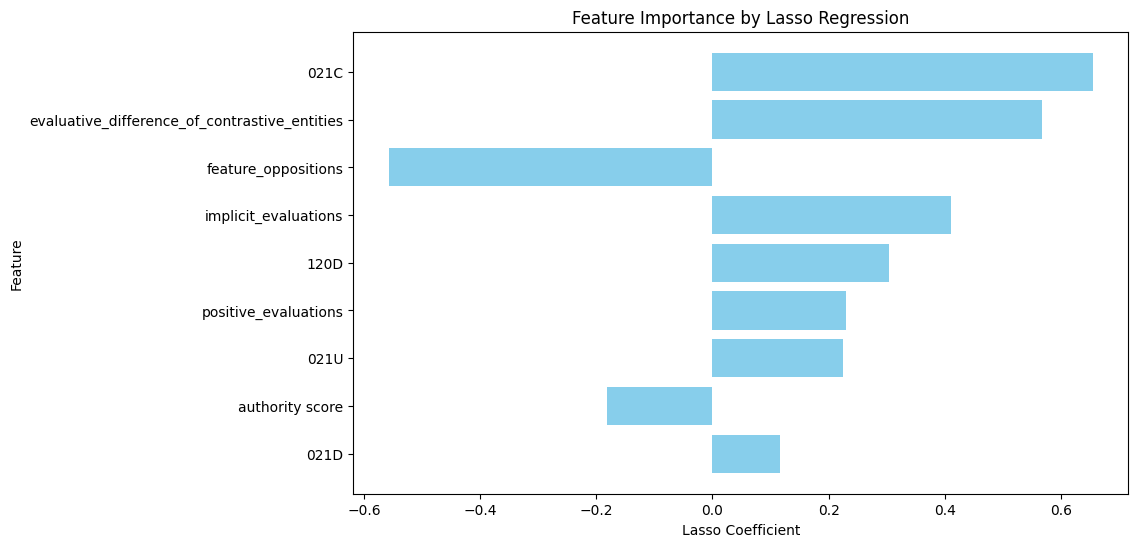

In [413]:
from sklearn.linear_model import LassoCV
import pandas as pd
import numpy as np

# Assuming X and y are already defined and cleaned
# X: Features
# y: Target variable (assertive_force_mean)

# Lasso Regression with Cross-Validation to tune alpha (regularization strength)
lasso = LassoCV(cv=5, max_iter=15000, alphas=np.logspace(-2, 1, 50), random_state=42).fit(X, y)

# Extract feature coefficients
lasso_coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
})

# Filter out features with zero coefficients
selected_features = lasso_coefficients[lasso_coefficients['Coefficient'] != 0]

# Sort features by absolute coefficient values
selected_features = selected_features.sort_values(by='Coefficient', key=np.abs, ascending=False)

# Display selected features
print("Selected Features:\n", selected_features)

# Plot the coefficients for visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(selected_features['Feature'], selected_features['Coefficient'], color='skyblue')
plt.xlabel('Lasso Coefficient')
plt.ylabel('Feature')
plt.title('Feature Importance by Lasso Regression')
plt.gca().invert_yaxis()
plt.show()


# kmeans

In [415]:
from sklearn.preprocessing import StandardScaler

# Use only features selected by Lasso
X_selected = X[selected_features['Feature'].values]

# Standardize the features (important for KMeans!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)



Clusters: 2, Silhouette Score: 0.3591
Clusters: 3, Silhouette Score: 0.2044
Clusters: 4, Silhouette Score: 0.2135
Clusters: 5, Silhouette Score: 0.2282
Clusters: 6, Silhouette Score: 0.2364
Clusters: 7, Silhouette Score: 0.2358
Clusters: 8, Silhouette Score: 0.2157
Clusters: 9, Silhouette Score: 0.2435
Clusters: 10, Silhouette Score: 0.2481


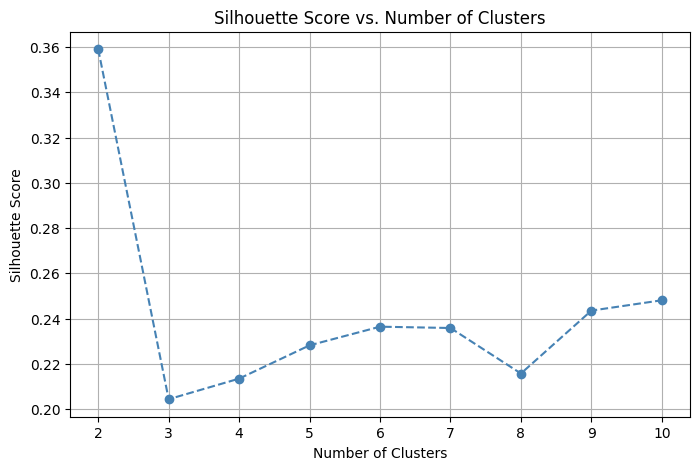

In [416]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Range of cluster numbers to try
range_n_clusters = range(2, 11)

# Store scores
silhouette_scores = []

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # Compute the silhouette score
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)
    print(f"Clusters: {n_clusters}, Silhouette Score: {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='--', color='steelblue')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(range_n_clusters)
plt.grid(True)
plt.show()


In [417]:
best_k = range_n_clusters[np.argmax(silhouette_scores)]

# Cluster (adjust n_clusters as needed)
n_clusters = best_k  # Example - choose based on your data
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Results
results = pd.DataFrame({
    'network': list(merged_df["file"]),
    'cluster': clusters
})
results

results.head()




,network,cluster
0,Heym_Die_Sektion.txt,0
1,Kleist_Chili_clean_neu.txt,0
2,Dorn_Vorsicht_Steinschlag.txt,0
3,Bobrowski_Brief_aus_Amerika.txt,0
4,Brecht_Müllers_natürliche_Haltung.txt,0


# Evaluation with f-score

In [366]:
# get labels

# Step 1: Clean both indexes by stripping '_split_network.graphml'
#df1.index = df1.index.astype(str).str.split('.txt').str[0]
df_assertion['file'] = df_assertion['Document_title'].astype(str).str.split('.txt').str[0]

# Step 2: Create a mapping from cleaned Document_title to assertive_clarity_cat
mapping_series = df_assertion.set_index('file')['assertive_clarity_cat']
#mapping_series = df_assertion.set_index('Document_title')['implicit_assertion_cat']
#mapping_series = df_assertion.set_index('Document_title')['assertive_clarity_cat']

"""
# Step 3: Create new index by combining assertive_clarity_cat + first 15 chars of filename
new_index = []
for fname in df1.index:
    cat = mapping_series.get(fname, "UNKNOWN")  # fallback if not found
    new_name = f"{cat}_{fname[:15]}"
    new_index.append(new_name)

# Step 4: Assign new index to average_df
df1.index = new_index
"""

'\n# Step 3: Create new index by combining assertive_clarity_cat + first 15 chars of filename\nnew_index = []\nfor fname in df1.index:\n    cat = mapping_series.get(fname, "UNKNOWN")  # fallback if not found\n    new_name = f"{cat}_{fname[:15]}"\n    new_index.append(new_name)\n\n# Step 4: Assign new index to average_df\ndf1.index = new_index\n'

In [367]:
true_labels_df = mapping_series
true_labels_df

,assertive_clarity_cat
file,
Aichinger_Das_Fenstertheater,HIGH
Altenberg_Die_Natur,LOW
Auerbach_Der_Kindesmord,HIGH
Bachmann_Arkadien_clean_neu,LOW
Bierbaum_Der_Mohr,HIGH
Bobrowski_Brief_aus_Amerika,LOW
Böll_Wanderer_kommst_du_nach_Spa_clean,HIGH
Brecht_Herr_Keuner_und_die_Schauspielerin,HIGH
Brecht_Müllers_natürliche_Haltung,LOW



Per-class metrics:
- LOW (0): Precision = 0.529, Recall = 1.000, F1 = 0.692
- HIGH (1):    Precision = 1.000, Recall = 0.059, F1 = 0.111

Macro F1:    0.402
Weighted F1: 0.410

Classification Report:
              precision    recall  f1-score   support

         LOW       0.53      1.00      0.69        18
        HIGH       1.00      0.06      0.11        17

    accuracy                           0.54        35
   macro avg       0.76      0.53      0.40        35
weighted avg       0.76      0.54      0.41        35


Missing networks analysis:
- In true labels but not in clustering results: 0
- In clustering results but not in true labels: 0


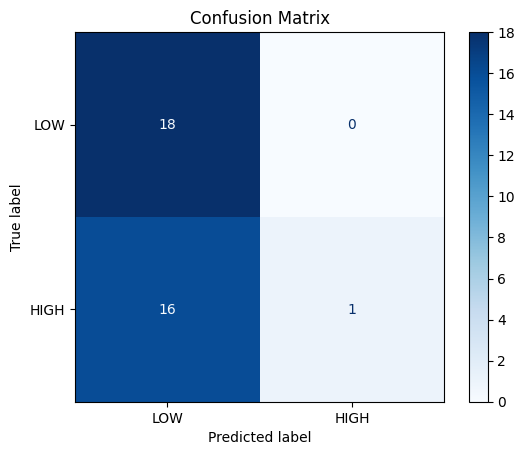

In [368]:
import pandas as pd

import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,  # <-- Add this import
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Assuming:
# - results_df (from clustering) has columns: 'network' and 'cluster'
# - true_labels_df has index 'Document_title' and column 'assertive_force_cat'

# 1. Prepare the dataframes
# Create base_name columns in both dataframes
results_df = results.copy()  # Make sure we're working with a DataFrame
results_df['base_name'] = results_df['network'].apply(lambda x: x.split('.txt')[0] if '.txt' in x else x)

# Reset index on true_labels_df to make Document_title a column
true_labels_df = true_labels_df.reset_index()
true_labels_df['base_name'] = true_labels_df['file'].apply(lambda x: x.split('.txt')[0] if '.txt' in x else x)

# 2. Merge the dataframes
merged = pd.merge(results_df, true_labels_df,
                 on='base_name',
                 how='inner')

if len(merged) == 0:
    raise ValueError("No matching networks found between clustering results and true labels")

# 3. Label clusters by majority vote
cluster_labels = {}
for cluster in merged['cluster'].unique():
    cluster_df = merged[merged['cluster'] == cluster]
    majority = cluster_df['assertive_clarity_cat'].mode()[0]  # Get most frequent label
    cluster_labels[cluster] = majority

# 4. Assign predicted labels
merged['predicted_label'] = merged['cluster'].map(cluster_labels)

# 5. Calculate extended metrics
# Convert labels to binary (if not already done)
label_map = {'HIGH': 1, 'LOW': 0}
merged['true_binary'] = merged['assertive_clarity_cat'].map(label_map)
merged['predicted_binary'] = merged['predicted_label'].map(label_map)

# Individual class precision/recall/F1
precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
    merged['true_binary'],
    merged['predicted_binary'],
    labels=[0, 1]  # LOW (0), HIGH (1)
)

# Macro F1 (unweighted mean across classes)
macro_f1 = f1_score(
    merged['true_binary'],
    merged['predicted_binary'],
    average='macro'
)

# Weighted F1 (weighted by support)
weighted_f1 = f1_score(
    merged['true_binary'],
    merged['predicted_binary'],
    average='weighted'
)

# Print results
print("\nPer-class metrics:")
print(f"- LOW (0): Precision = {precision_per_class[0]:.3f}, Recall = {recall_per_class[0]:.3f}, F1 = {f1_per_class[0]:.3f}")
print(f"- HIGH (1):    Precision = {precision_per_class[1]:.3f}, Recall = {recall_per_class[1]:.3f}, F1 = {f1_per_class[1]:.3f}")
print(f"\nMacro F1:    {macro_f1:.3f}")
print(f"Weighted F1: {weighted_f1:.3f}")

# Alternative: Full classification report (includes all metrics)
print("\nClassification Report:")
print(classification_report(
    merged['true_binary'],
    merged['predicted_binary'],
    target_names=['LOW', 'HIGH']
))

# 6. Show missing networks (optional)
missing_in_results = set(true_labels_df['base_name']) - set(results_df['base_name'])
missing_in_labels = set(results_df['base_name']) - set(true_labels_df['base_name'])

print("\nMissing networks analysis:")
print(f"- In true labels but not in clustering results: {len(missing_in_results)}")
if missing_in_results:
    print("  Examples:", list(missing_in_results)[:3])
print(f"- In clustering results but not in true labels: {len(missing_in_labels)}")
if missing_in_labels:
    print("  Examples:", list(missing_in_labels)[:3])

# 7. Confusion matrix (optional)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(merged['true_binary'], merged['predicted_binary'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=['LOW', 'HIGH'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [369]:
# Generate the classification report as a string
report_str = classification_report(
    merged['true_binary'],
    merged['predicted_binary'],
    target_names=['LOW', 'HIGH'],
    output_dict=False  # This returns a string
)

# Convert the string report to a dictionary (which pandas can easily convert to DataFrame)
report_dict = classification_report(
    merged['true_binary'],
    merged['predicted_binary'],
    target_names=['LOW', 'HIGH'],
    output_dict=True  # This returns a dictionary
)

# Convert the dictionary to a DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Save to Excel
report_df.to_excel("portrait_classification_report_force.xlsx")

print("Classification report saved to 'classification_report.xlsx'")

Classification report saved to 'classification_report.xlsx'


In [370]:
results_df

,network,cluster,base_name
0,Heym_Die_Sektion.txt,0,Heym_Die_Sektion
1,Kleist_Chili_clean_neu.txt,0,Kleist_Chili_clean_neu
2,Dorn_Vorsicht_Steinschlag.txt,0,Dorn_Vorsicht_Steinschlag
3,Bobrowski_Brief_aus_Amerika.txt,0,Bobrowski_Brief_aus_Amerika
4,Brecht_Müllers_natürliche_Haltung.txt,0,Brecht_Müllers_natürliche_Haltung
5,Stamm_Das_schönste_Mädchen.txt,0,Stamm_Das_schönste_Mädchen
6,Heckmann_Das_Henkersmahl.txt,0,Heckmann_Das_Henkersmahl
7,Böll_Wanderer_kommst_du_nach_Spa_clean.txt,0,Böll_Wanderer_kommst_du_nach_Spa_clean
8,Franck_Streuselschnecke.txt,0,Franck_Streuselschnecke
9,Brecht_Herr_Keuner_und_die_Schauspielerin.txt,0,Brecht_Herr_Keuner_und_die_Schauspielerin


In [371]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(merged['assertive_clarity_cat'], merged['cluster'])
#ari = adjusted_rand_score(merged['assertive_clarity_cat'], merged['cluster'])

print(f"Adjusted Rand Index: {ari:.3f}")
# Interpretation: 1=perfect match, 0=random, negative=worse than random

Adjusted Rand Index: 0.003


In [372]:
merged

,network,cluster,base_name,file,assertive_clarity_cat,predicted_label,true_binary,predicted_binary
0,Heym_Die_Sektion.txt,0,Heym_Die_Sektion,Heym_Die_Sektion,LOW,LOW,0,0
1,Kleist_Chili_clean_neu.txt,0,Kleist_Chili_clean_neu,Kleist_Chili_clean_neu,HIGH,LOW,1,0
2,Dorn_Vorsicht_Steinschlag.txt,0,Dorn_Vorsicht_Steinschlag,Dorn_Vorsicht_Steinschlag,LOW,LOW,0,0
3,Bobrowski_Brief_aus_Amerika.txt,0,Bobrowski_Brief_aus_Amerika,Bobrowski_Brief_aus_Amerika,LOW,LOW,0,0
4,Brecht_Müllers_natürliche_Haltung.txt,0,Brecht_Müllers_natürliche_Haltung,Brecht_Müllers_natürliche_Haltung,LOW,LOW,0,0
5,Stamm_Das_schönste_Mädchen.txt,0,Stamm_Das_schönste_Mädchen,Stamm_Das_schönste_Mädchen,LOW,LOW,0,0
6,Heckmann_Das_Henkersmahl.txt,0,Heckmann_Das_Henkersmahl,Heckmann_Das_Henkersmahl,LOW,LOW,0,0
7,Böll_Wanderer_kommst_du_nach_Spa_clean.txt,0,Böll_Wanderer_kommst_du_nach_Spa_clean,Böll_Wanderer_kommst_du_nach_Spa_clean,HIGH,LOW,1,0
8,Franck_Streuselschnecke.txt,0,Franck_Streuselschnecke,Franck_Streuselschnecke,LOW,LOW,0,0
9,Brecht_Herr_Keuner_und_die_Schauspielerin.txt,0,Brecht_Herr_Keuner_und_die_Schauspielerin,Brecht_Herr_Keuner_und_die_Schauspielerin,HIGH,LOW,1,0


In [373]:
# Count predicted labels per cluster
predicted_counts = merged.groupby('cluster')['predicted_label'].value_counts().unstack(fill_value=0)

print("Predicted counts per cluster:")
print(predicted_counts)

Predicted counts per cluster:
predicted_label  HIGH  LOW
cluster                   
0                   0   34
1                   1    0


In [374]:
# Count true labels per cluster
true_label_counts = merged.groupby('cluster')['true_binary'].value_counts().unstack(fill_value=0)

print("true label counts per cluster (0 = LOW, 1 = HIGH):")
print(true_label_counts)

true label counts per cluster (0 = LOW, 1 = HIGH):
true_binary   0   1
cluster            
0            18  16
1             0   1


In [375]:
# Create a new column indicating correct/incorrect classification
merged['correct'] = merged['true_binary'] == merged['predicted_binary']

# Initialize dictionaries to store results
cluster_results = {
    0: {'correct': [], 'incorrect': []},
    1: {'correct': [], 'incorrect': []},
    2: {'correct': [], 'incorrect': []}
}

# Iterate through each row and classify
for _, row in merged.iterrows():
    cluster = row['cluster']
    network = row['network']

    if row['correct']:
        cluster_results[cluster]['correct'].append(network)
    else:
        cluster_results[cluster]['incorrect'].append(network)

# Print results
for cluster in sorted(cluster_results.keys()):
    print(f"\nCluster {cluster}:")
    print(f"Correctly classified ({len(cluster_results[cluster]['correct'])}):")
    print(cluster_results[cluster]['correct'])

    print(f"\nIncorrectly classified ({len(cluster_results[cluster]['incorrect'])}):")
    print(cluster_results[cluster]['incorrect'])


Cluster 0:
Correctly classified (18):
['Heym_Die_Sektion.txt', 'Dorn_Vorsicht_Steinschlag.txt', 'Bobrowski_Brief_aus_Amerika.txt', 'Brecht_Müllers_natürliche_Haltung.txt', 'Stamm_Das_schönste_Mädchen.txt', 'Heckmann_Das_Henkersmahl.txt', 'Franck_Streuselschnecke.txt', 'Hebel_Unverhofftes_Wiedersehen.txt', 'Mann_Beim_Propheten_clean.txt', 'Reventlow_Der_feine_Dieb.txt', 'Bachmann_Arkadien_clean_neu.txt', 'Roth_Der_stumme_Prophet_Fragment_gb_clean_neu.txt', 'Wendt_Tote_Vögel.txt', 'Langgässer_Die_Sippe_auf_dem_Berg_und_im_Tal.txt', 'Mann_Der_Geburtstag_der_Frau_Baronin.txt', 'Altenberg_Die_Natur.txt', 'Kafka_Bericht_für_eine_Akademie_neu.txt', 'Walser_Der_Nachen.txt']

Incorrectly classified (16):
['Kleist_Chili_clean_neu.txt', 'Böll_Wanderer_kommst_du_nach_Spa_clean.txt', 'Brecht_Herr_Keuner_und_die_Schauspielerin.txt', 'Storm_Im_Saal.txt', 'Bierbaum_Der_Mohr.txt', 'Grimm_Frau_Holle_clean_neu.txt', 'Tucholsky_Märchen.txt', 'Grimm_Das_tapfere_Schneiderlein.txt', 'Wolf_Der_Stern_der_Schö

# hierarchical

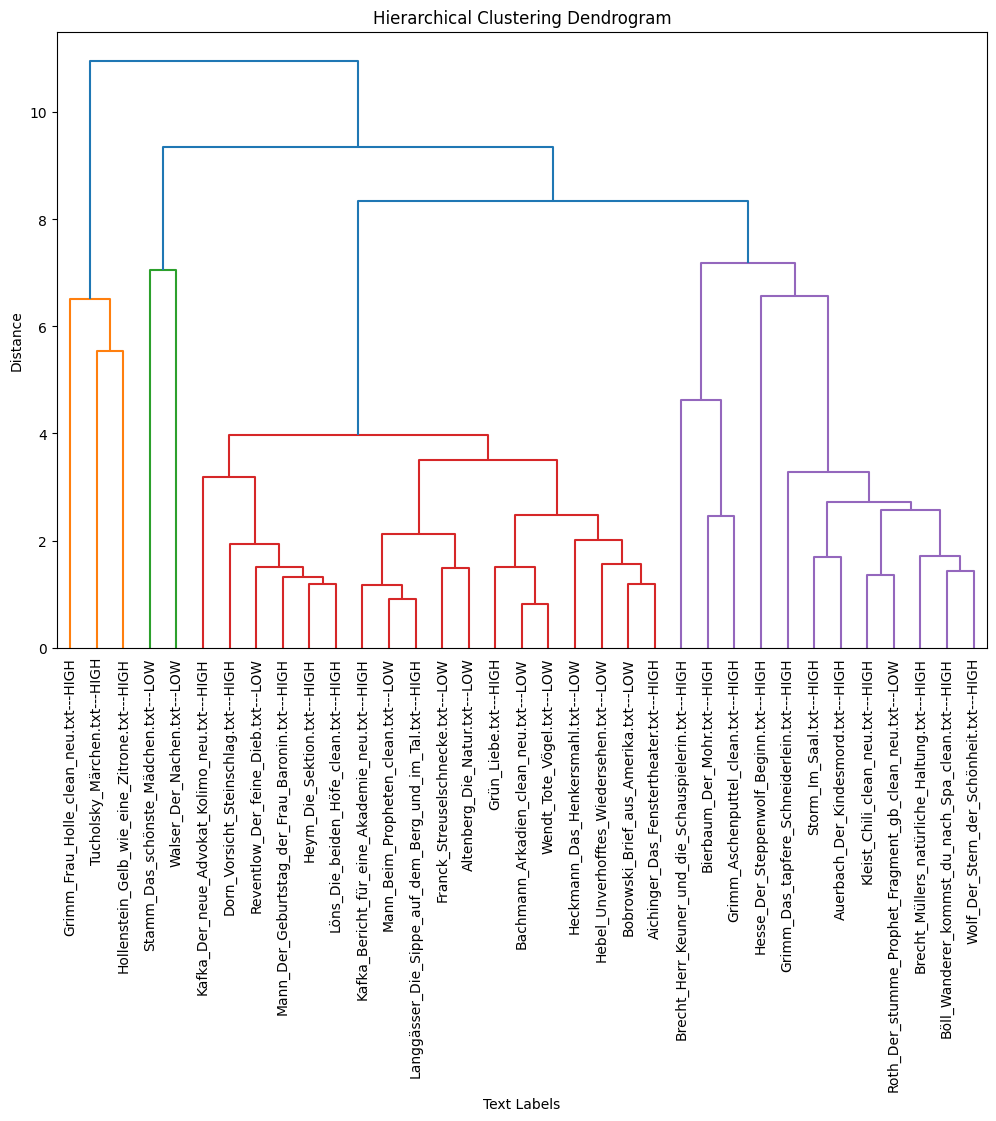

In [418]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

text_labels = merged_df["Document_title_with_cat"]

# Step 1: Extract data based on selected features
selected_feature_names = selected_features['Feature'].tolist()  # From Lasso step
X_selected = X[selected_feature_names]

# Step 2: Standardize the data (a second time?)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# Step 3: Compute linkage matrix for hierarchical clustering
# You can use different methods for linkage: 'ward', 'single', 'complete', 'average'
linkage_matrix = linkage(X_scaled, method='ward')

# Step 4: Plot dendrogram
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=text_labels.tolist(), leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Text Labels")
plt.ylabel("Distance")
plt.show()

# Step 5: Extract cluster labels
# Choose the number of clusters using a threshold on the dendrogram
num_clusters = 4  # Adjust as needed
cluster_labels = fcluster(linkage_matrix, t=num_clusters, criterion='maxclust')

# Map cluster labels to text labels
clustered_data = pd.DataFrame({
    'Text_Label': text_labels,
    'Cluster_Label': cluster_labels
})

#print(clustered_data.sort_values(by='Cluster_Label'))


In [419]:
from sklearn.metrics import silhouette_score

# Silhouette score
silhouette_avg = silhouette_score(X_selected, cluster_labels)
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.20976552069863635


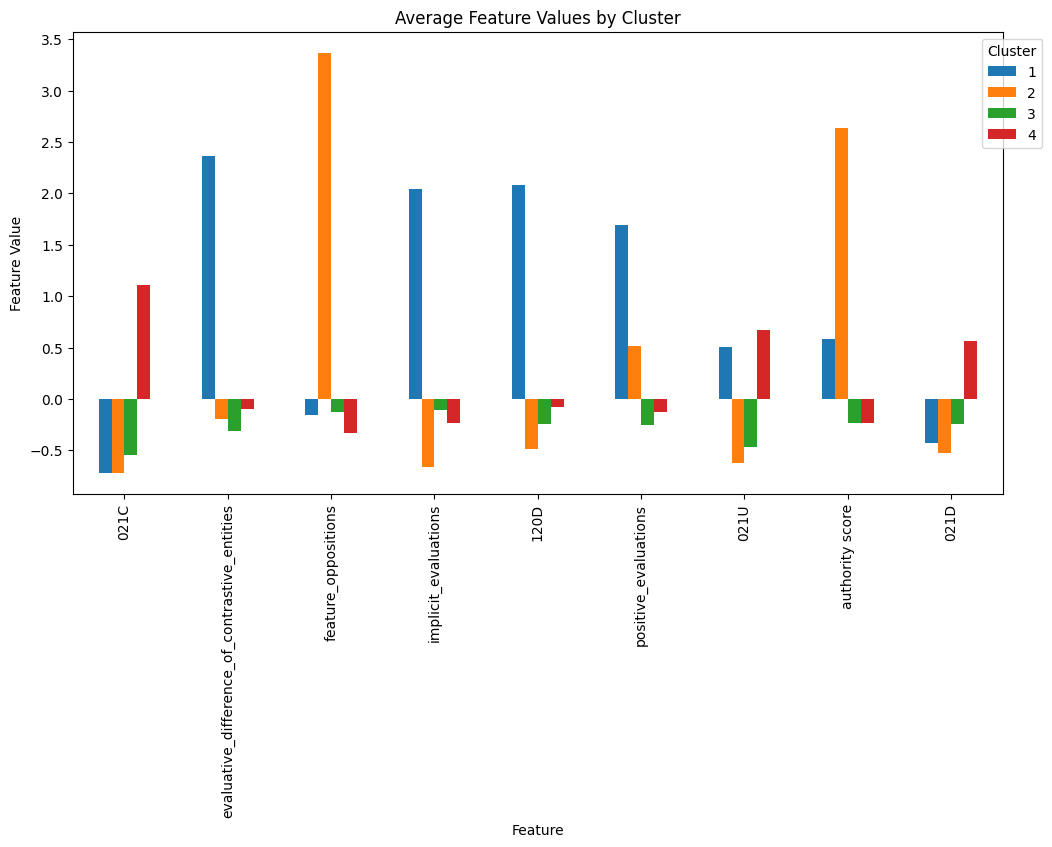

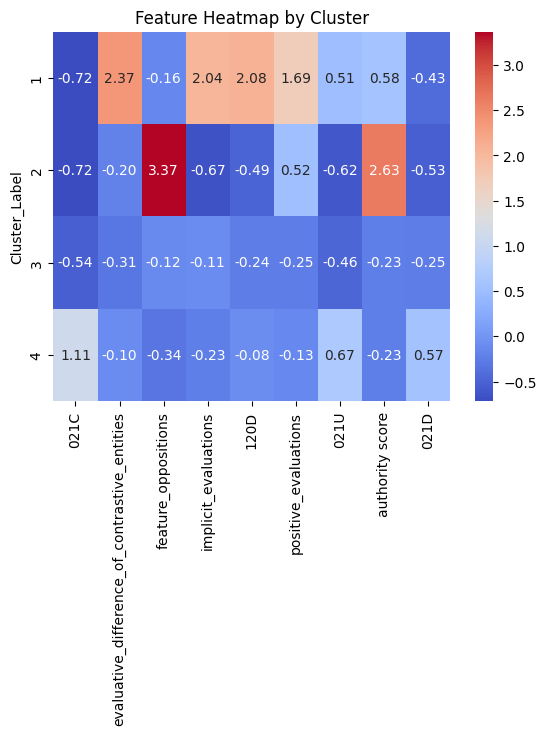

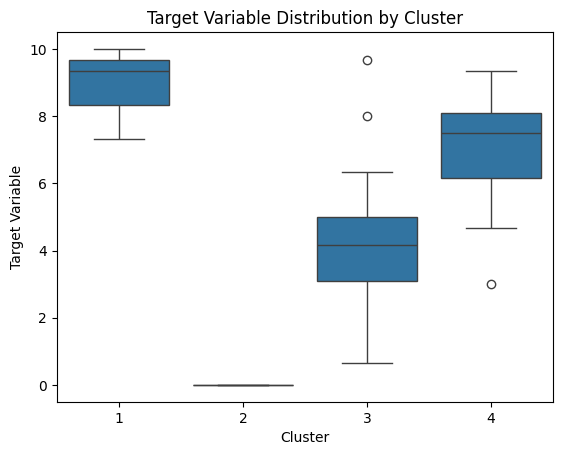

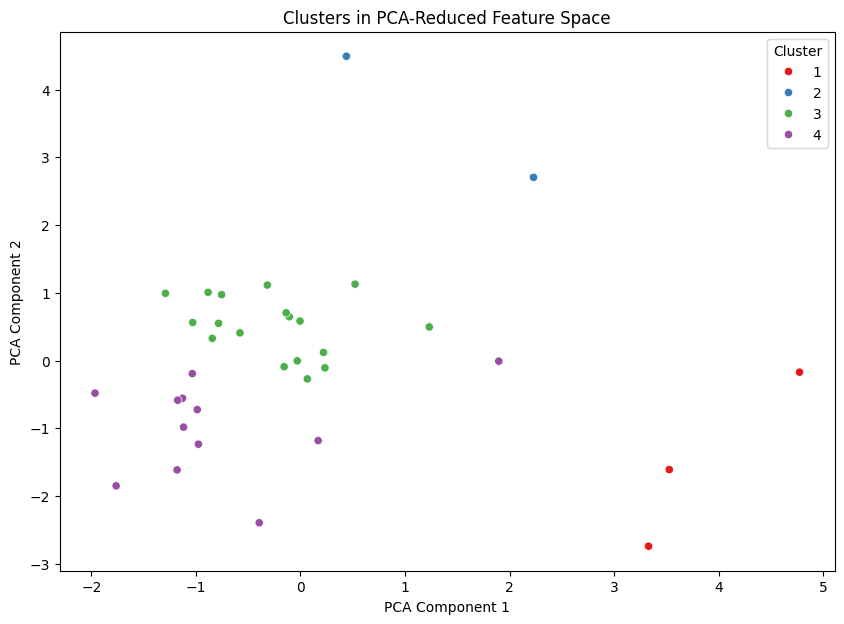

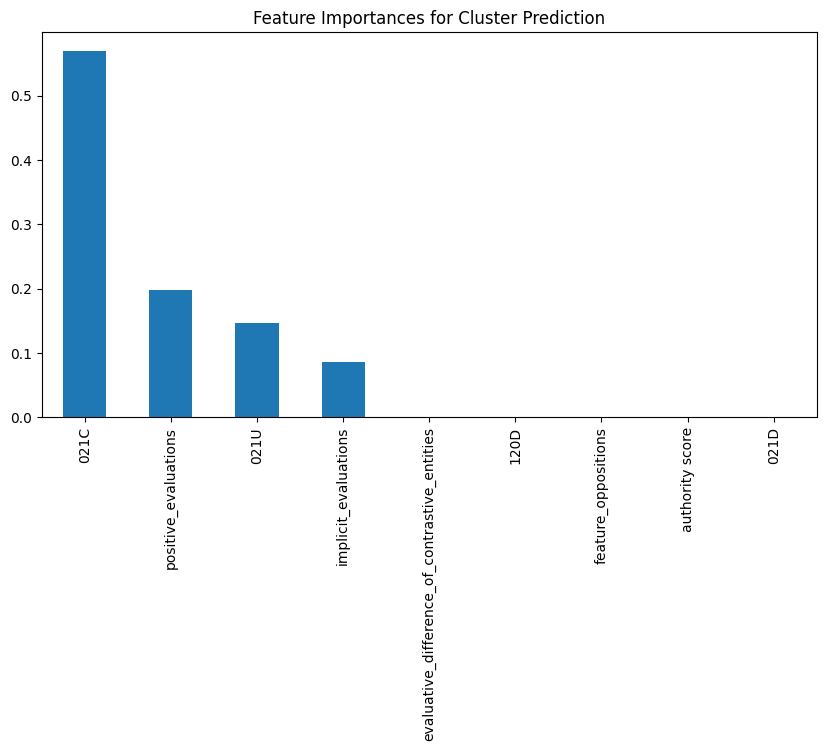

In [420]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier

# Merge cluster labels, selected features, and target variable
clustered_data = pd.DataFrame({
    'Text_Label': text_labels,
    'Cluster_Label': cluster_labels
})
X_selected['Cluster_Label'] = cluster_labels
summary = X_selected.groupby('Cluster_Label').mean()
summary_y = pd.concat([y, pd.Series(cluster_labels, name='Cluster_Label')], axis=1).groupby('Cluster_Label').mean()

# Plot feature averages by cluster
summary.T.plot(kind='bar', figsize=(12, 6))
plt.title('Average Feature Values by Cluster')
plt.ylabel('Feature Value')
plt.xlabel('Feature')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1))
plt.show()

# Heatmap of feature averages by cluster
sns.heatmap(summary, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Heatmap by Cluster')
plt.show()

# Boxplots for target variable by cluster
sns.boxplot(x=cluster_labels, y=y)
plt.title('Target Variable Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Target Variable')
plt.show()

# PCA for cluster visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_selected.drop('Cluster_Label', axis=1))
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='Set1')
plt.title('Clusters in PCA-Reduced Feature Space')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

# Feature importance for predicting clusters
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X_selected.drop('Cluster_Label', axis=1), cluster_labels)
importances = pd.Series(clf.feature_importances_, index=X_selected.columns[:-1])
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 5))
plt.title('Feature Importances for Cluster Prediction')
plt.show()


In [421]:
clustered_data

,Text_Label,Cluster_Label
0,Heym_Die_Sektion.txt---HIGH,3
1,Kleist_Chili_clean_neu.txt---HIGH,4
2,Dorn_Vorsicht_Steinschlag.txt---HIGH,3
3,Bobrowski_Brief_aus_Amerika.txt---LOW,3
4,Brecht_Müllers_natürliche_Haltung.txt---HIGH,4
5,Stamm_Das_schönste_Mädchen.txt---LOW,2
6,Heckmann_Das_Henkersmahl.txt---LOW,3
7,Böll_Wanderer_kommst_du_nach_Spa_clean.txt---HIGH,4
8,Franck_Streuselschnecke.txt---LOW,3
9,Brecht_Herr_Keuner_und_die_Schauspielerin.txt-...,4


# SANDBOX

In [ ]:
from IPython.display import HTML
# Step 1: Install necessary libraries if not already installed
!pip install networkx matplotlib
!pip install pyvis

# Step 3: Import libraries
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
# Step 4: Load the GraphML file
# Replace 'your_file_path.graphml' with the path to your GraphML file in Google Drive
file_path = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/evaluative_network_with_oppositions_graphml_20241031/Dorn_Vorsicht_Steinschlag.txt_evaluative_network_with_oppositions.graphml.xml'

# Read the graph
nx.read_graphml(file_path, node_type=str)

"""
# Step 5: Visualize the graph
plt.figure(figsize=(10, 10))
nx.draw(G, with_labels=True, node_size=500, node_color='lightblue', font_size=10, font_weight='bold')
plt.show()
"""
import networkx as nx
from pyvis.network import Network

# Load the GEXF file
G_loaded = nx.read_graphml(file_path, force_multigraph=True)

# Initialize a pyvis Network instance
nt = Network(notebook=True, directed=True, cdn_resources='in_line')

# Add nodes with their attributes
for node, data in G_loaded.nodes(data=True):
    nt.add_node(node, size=data.get("size", 10))  # Adjust size if needed

# Add edges with custom attributes
for u, v, key, data in G_loaded.edges(keys=True, data=True):
    nt.add_edge(u, v, label=data.get("label", ""), color=data.get("color", "black"))

# Optionen für das Layout des Graphen festlegen
nt.barnes_hut()
nt.options.physics.enabled = True
nt.options.edges.smooth = True
nt.options.edges.smooth = {"type": "curvedCCW"}

# Node- und Kantenbeschriftungen aktivieren
#nt.show_buttons()
nt.toggle_physics(False)


# Kantenbreite und -farbe anpassen
nt.options.edges.width = 1
nt.options.edges.color = {"inherit":False}
nt.options.edges.font = {"size": 10, "color": "#444444"}

plt.show(block=False)
plt.savefig("Graph.png", format="PNG")
# Display the network
nt.show("network.html")

# nur in colab
display(HTML("network.html"))


network.html


<Figure size 640x480 with 0 Axes>

In [ ]:
nt.draw(G_loaded, with_labels=True, node_size=500, node_color='lightblue', font_size=10, font_weight='bold')
plt.savefig("dateiname.svg")

AttributeError: 'Network' object has no attribute 'draw'

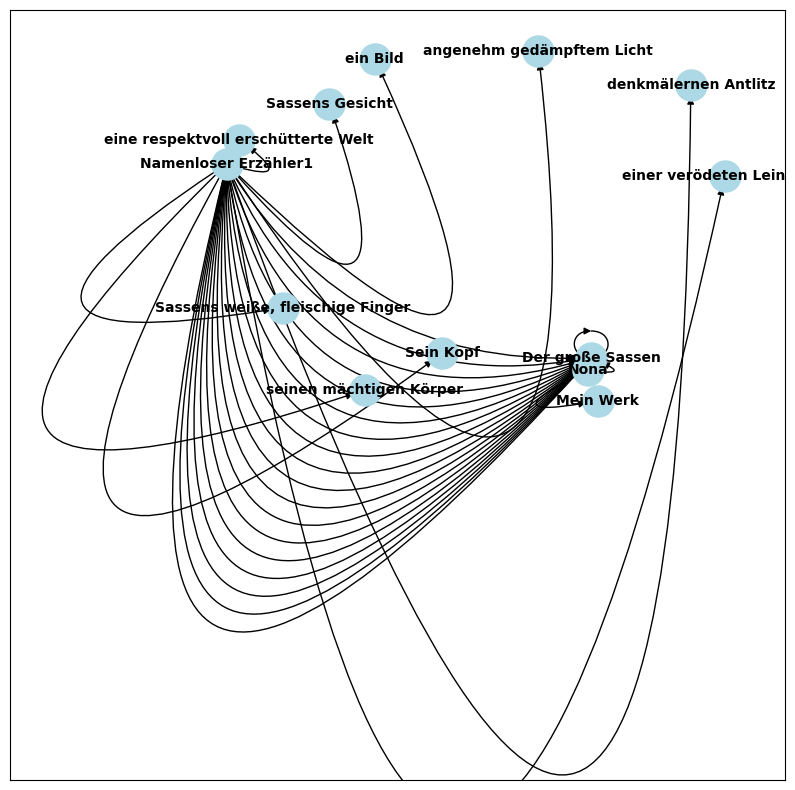

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Example to draw multi-edges with curvature
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G_loaded)

# Draw nodes and edges
nx.draw_networkx_nodes(G_loaded, pos, node_size=500, node_color='lightblue')
nx.draw_networkx_labels(G_loaded, pos, font_size=10, font_weight='bold')

# Draw edges with curvature
for key, (u, v, data) in enumerate(G_loaded.edges(keys=False, data=True)):
    nx.draw_networkx_edges(
        G_loaded, pos,
        edgelist=[(u, v)],
        connectionstyle=f"arc3,rad={0.3 + 0.1 * key}"  # Adjust rad for distinct curvature
    )

# Show plot
plt.show()


In [ ]:
G= G_loaded

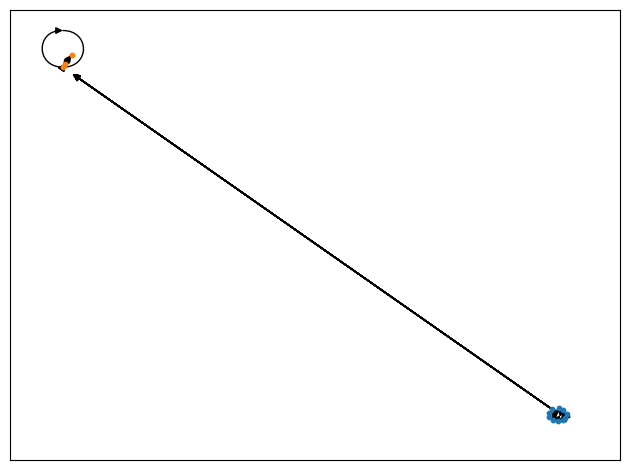

In [ ]:
communities = nx.community.greedy_modularity_communities(G)

# Compute positions for the node clusters as if they were themselves nodes in a
# supergraph using a larger scale factor
supergraph = nx.cycle_graph(len(communities))
superpos = nx.spring_layout(G, scale=50, seed=429)

# Use the "supernode" positions as the center of each node cluster
centers = list(superpos.values())
pos = {}
for center, comm in zip(centers, communities):
    pos.update(nx.spring_layout(nx.subgraph(G, comm), center=center, seed=1430))

# Nodes colored by cluster
for nodes, clr in zip(communities, ("tab:blue", "tab:orange", "tab:green")):
    nx.draw_networkx_nodes(G, pos=pos, nodelist=nodes, node_color=clr, node_size=10)
nx.draw_networkx_edges(G, pos=pos)

plt.tight_layout()
plt.show()

In [ ]:
communities

[frozenset({'Namenloser Erzähler1',
            'Sassens Gesicht',
            'Sassens weiße, fleischige Finger',
            'Sein Kopf',
            'angenehm gedämpftem Licht',
            'denkmälernen Antlitz',
            'ein Bild',
            'eine respektvoll erschütterte Welt',
            'einer verödeten Leinwand',
            'seinen mächtigen Körper'}),
 frozenset({'Der große Sassen', 'Mein Werk', 'Nona'})]

In [ ]:
#file_path = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/evaluative_network_with_oppositions_graphml_20241031/Dorn_Vorsicht_Steinschlag.txt_evaluative_network_with_oppositions.graphml.xml'
#file_path = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/evaluative_network_with_oppositions_graphml_20241031/Roth_Der_stumme_Prophet_Fragment_gb_clean.txt_evaluative_network_with_oppositions.graphml.xml'
file_path = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/evaluative_network_with_oppositions_graphml_20241031/Grimm_Frau_Holle_clean.txt_evaluative_network_with_oppositions.graphml.xml'

# Read the graph
G= nx.read_graphml(file_path, node_type=str)

In [ ]:
from networkx.algorithms.community import greedy_modularity_communities
communities = list(greedy_modularity_communities(G))
print(len(communities))
communities  # Each set is a cluster of nodes


3


[frozenset({'Eine Wittwe',
            'Frau Holle',
            'Namenloser Erzähler1',
            'ein gutes Leben',
            'einer schönen Wiese'}),
 frozenset({'Autor', 'die andere', 'die eine'}),
 frozenset({'Haus', 'einem kleinen Haus'})]

In [ ]:
G_summarized = nx.MultiDiGraph()
for u, v, data in G.edges(data=True):
    weight = data.get('weight', 1)
    if G_summarized.has_edge(u, v):
        G_summarized[u][v][0]['weight'] += weight
    else:
        G_summarized.add_edge(u, v, weight=weight)

dense_edges = [
    (u, v, k)
    for u, v, k, data in G_summarized.edges(data=True, keys=True)
    if data['weight'] > 2
]
dense_subgraph = G_summarized.edge_subgraph(dense_edges)

dense_subgraph = G_summarized.edge_subgraph(dense_edges)
dense_subgraph


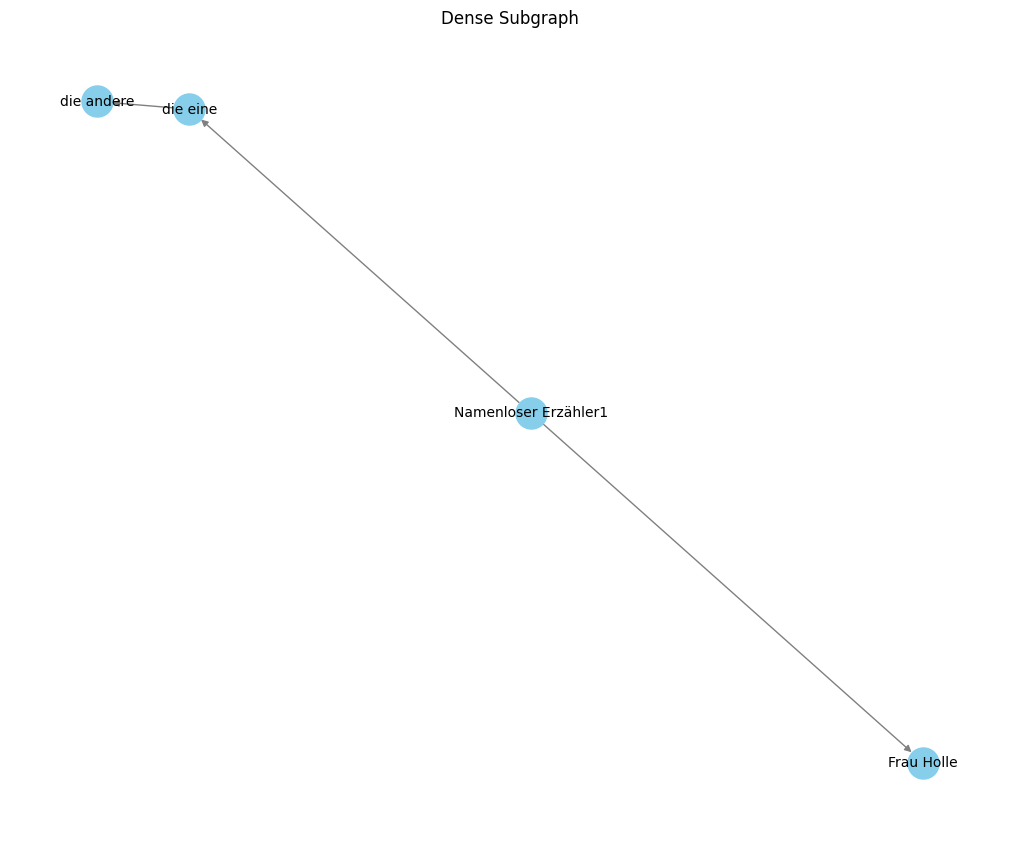

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a layout for better visualization
pos = nx.spring_layout(dense_subgraph)  # Spring layout for node placement

# Draw the graph
plt.figure(figsize=(10, 8))
nx.draw(
    dense_subgraph,
    pos,
    with_labels=True,
    node_color='skyblue',
    edge_color='gray',
    node_size=500,
    font_size=10
)
plt.title("Dense Subgraph")
plt.show()


In [ ]:
def compute_multidigraph_edge_density(graph):
    """
    Computes the edge density for a MultiDiGraph, considering parallel edges.

    Parameters:
        graph (networkx.MultiDiGraph): The input MultiDiGraph.

    Returns:
        float: The edge density of the graph.
    """
    num_nodes = graph.number_of_nodes()
    num_edges = graph.number_of_edges()  # Includes all parallel edges

    if num_nodes < 2:
        return 0  # Edge density is zero if there are fewer than 2 nodes

    # Total possible edges in a directed graph (ignoring parallel edges)
    total_possible_edges = num_nodes * (num_nodes - 1)

    # Edge density (averaged across all possible pairs)
    edge_density = num_edges / total_possible_edges
    return edge_density

# Example: MultiDiGraph with parallel edges
import networkx as nx


print("Edge Density:", compute_multidigraph_edge_density(G))


Edge Density: 0.3888888888888889


# Components

In [ ]:
list(nx.weakly_connected_components(G))

[{'Der Marine-Offizier',
  'Don Fernando',
  'Don Fernandos beiden Schwägerinnen',
  'Don Henrico Asteron',
  'Don Pedro',
  'Donna Elisabeth',
  'Donna Elvire',
  'Donna Josephe',
  'Gott',
  'Ihr Unmenschlichen',
  'Jeronimo Rugera',
  'Meister Pedrillo',
  'Menschen',
  'Menschen von allen Ständen',
  'Namenloser Erzähler1',
  'Philipp',
  'St. Jago',
  'Tale',
  'an diesem fürchterlichen Tag',
  'das Unrecht',
  'das Weltgericht',
  'das allgemeine Unglück',
  'dem Augenblicke der großen Erderschütterung vom Jahre 1647',
  'dem Besitzer',
  'dem fürchterlichen Schlage',
  'dem nichtswürdigsten Gute',
  'den fanatischen Mordknecht',
  'den schrecklichsten Augenblicken',
  'den verfloßnen Tag',
  'der Täter',
  'der gefürchtete Tag',
  'der heiligen Mutter Gottes',
  'der nichtssagenden Unterhaltungen',
  'der Äbtissin',
  'der ältesten Chorherren einer',
  'des Himmels',
  'die Mordknechte',
  'die Orgel',
  'die frommen Töchter der Stadt',
  'die schönste Nacht',
  'die verstörten 

In [ ]:
list(nx.strongly_connected_components(G))

[{'den Niedergang des Theaters'},
 {'der Lärm der Propeller'},
 {'der Propeller'},
 {'einem dieser hübschen stählernen Dinger'},
 {'die Flugleitung'},
 {'Fliegen'},
 {'der Pilot'},
 {'Der «Versuch»'},
 {'die gewisse Unordnung'},
 {'deiner seriösen Kluft'},
 {'seinen dicken Kopf'},
 {'Müller'},
 {'schlechtem Wetter'},
 {'der unangenehme Teil der Geschichte'},
 {'solch ein wahnsinniges Gewäsch'},
 {'sein Verhalten von heute morgen'},
 {'Ein Mensch'},
 {'die natürliche Haltung'},
 {'Müllers', 'Pucher'},
 {'ein unfehlbarer Zankapfel'},
 {'Namenloser Erzähler1'},
 {'Autor'},
 {'blauen Himmel'},
 {'Flugzeug'}]

In [ ]:
import pylab as plt
from networkx.drawing.nx_agraph import graphviz_layout
import pygraphviz

#G = nx.erdos_renyi_graph(30,.05)
target_node = "Namenloser Erzähler1"

#pos=nx.graphviz_layout(G,prog="neato")

for h in nx.strongly_connected_components(G):
    if target_node in h:
        nx.draw(G, pos=graphviz_layout(G), node_size=1600, cmap=plt.cm.Blues,
        node_color=red,
        prog='dot')
    else:
        nx.draw(G, pos=graphviz_layout(G), node_size=1600, cmap=plt.cm.Blues,
        node_color=white,
        prog='dot')

plt.show()

In [ ]:
(G.subgraph(c) for c in nx.strongly_connected_components(G))

<generator object <genexpr> at 0x7e0ed0290cf0>

In [ ]:
file_path1 = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/evaluative_network_with_oppositions_graphml_20241031/Dorn_Vorsicht_Steinschlag.txt_evaluative_network_with_oppositions.graphml.xml'
file_path2 = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/evaluative_network_with_oppositions_graphml_20241031/Roth_Der_stumme_Prophet_Fragment_gb_clean.txt_evaluative_network_with_oppositions.graphml.xml'
file_path3 = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/evaluative_network_with_oppositions_graphml_20241031/Grimm_Frau_Holle_clean.txt_evaluative_network_with_oppositions.graphml.xml'
file_path = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/evaluative_network_with_oppositions_graphml_20241031/Brecht_Müllers_natürliche_Haltung.txt_evaluative_network_with_oppositions.graphml.xml'
#file_path = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/evaluative_network_with_oppositions_graphml_20241031/Kleist_Chili_clean.txt_evaluative_network_with_oppositions.graphml.xml'


# Read the graph
G= nx.read_graphml(file_path, node_type=str)

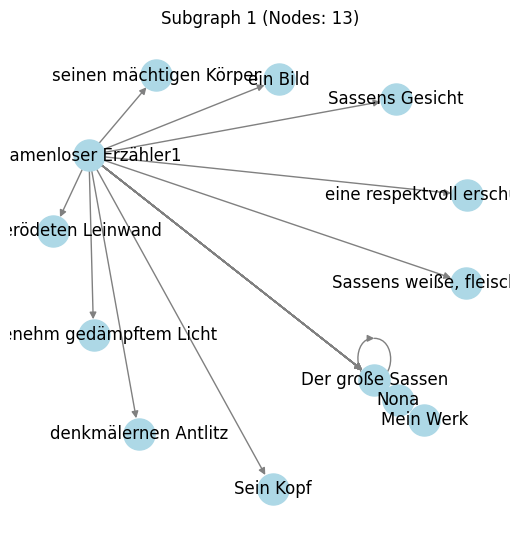

In [ ]:

# Generate and draw each strongly connected subgraph with more than one node
for i, c in enumerate(nx.weakly_connected_components(G)):
    if len(c) > 1:  # Only include subgraphs with more than one node
        subgraph = G.subgraph(c)
        plt.figure(figsize=(5, 5))
        nx.draw(subgraph, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500)
        plt.title(f"Subgraph {i+1} (Nodes: {len(c)})")
        plt.show()

In [ ]:
sum(1 for c in nx.strongly_connected_components(G) if len(c) > 1)

1

# Triaden

In [ ]:
import networkx as nx

# Example directed graph
#G = nx.DiGraph()
#G.add_edges_from([(1, 2), (2, 3), (3, 1), (3, 4), (4, 5)])

# Triadic census
census = nx.triadic_census(G)
print(census)

# Total number of triads (sum of all triads in the census)
total_triads = sum(census.values())
print(f"Total number of triads: {total_triads}")
census["120D"]


{'003': 0, '012': 0, '102': 0, '021D': 0, '021U': 0, '021C': 0, '111D': 0, '111U': 0, '030T': 0, '030C': 0, '201': 0, '120D': 0, '120U': 0, '120C': 1, '210': 0, '300': 0}
Total number of triads: 1


0

# HITS

In [ ]:
#Authorities estimates the node value based on the incoming links (= wer wird oft gewertet).
#Hubs estimates the node value based on outgoing links (= wer hat Wertungsmacht).
h, a = nx.hits(G)
print(h)
print(a)

{'Namenloser Erzähler1': 0.005220538451095253, 'den Niedergang des Theaters': 0.0, 'Müllers': 1.0748088085600203, 'ein unfehlbarer Zankapfel': 0.0, 'Pucher': -0.09921351042091858, 'einem dieser hübschen stählernen Dinger': 0.0, 'der Lärm der Propeller': 0.0, 'der Propeller': 0.0, 'seinen dicken Kopf': 0.0, 'Müller': 0.0, 'schlechtem Wetter': 0.0, 'die Flugleitung': 0.0, 'Fliegen': 0.0, 'der Pilot': 0.0, 'Der «Versuch»': 0.0, 'der unangenehme Teil der Geschichte': 0.0, 'die gewisse Unordnung': 0.0, 'deiner seriösen Kluft': 0.0, 'solch ein wahnsinniges Gewäsch': 0.0, 'sein Verhalten von heute morgen': 0.0, 'Ein Mensch': 0.0, 'die natürliche Haltung': 0.0, 'Autor': 0.01742611930368477, 'blauen Himmel': 0.0017580441061183678, 'Flugzeug': 1.5236383170197416e-18}
{'Namenloser Erzähler1': 9.758258903146186e-17, 'den Niedergang des Theaters': 0.00019916387561978792, 'Müllers': 0.07570034516544755, 'ein unfehlbarer Zankapfel': 0.0001991638756197725, 'Pucher': 0.3356022015383741, 'einem dieser h

In [ ]:
import pprint

# Sort dictionaries by values in descending order
sorted_h = dict(sorted(h.items(), key=lambda item: item[1], reverse=True))
sorted_a = dict(sorted(a.items(), key=lambda item: item[1], reverse=True))

# Pretty print sorted dictionaries
print("Hub Scores (Descending):")
pprint.pprint(sorted_h, sort_dicts=False)

print("\nAuthority Scores (Descending):")
pprint.pprint(sorted_a, sort_dicts=False)

Hub Scores (Descending):
{'Müllers': 1.0748088085600203,
 'Autor': 0.01742611930368477,
 'Namenloser Erzähler1': 0.005220538451095253,
 'blauen Himmel': 0.0017580441061183678,
 'Flugzeug': 1.5236383170197416e-18,
 'den Niedergang des Theaters': 0.0,
 'ein unfehlbarer Zankapfel': 0.0,
 'einem dieser hübschen stählernen Dinger': 0.0,
 'der Lärm der Propeller': 0.0,
 'der Propeller': 0.0,
 'seinen dicken Kopf': 0.0,
 'Müller': 0.0,
 'schlechtem Wetter': 0.0,
 'die Flugleitung': 0.0,
 'Fliegen': 0.0,
 'der Pilot': 0.0,
 'Der «Versuch»': 0.0,
 'der unangenehme Teil der Geschichte': 0.0,
 'die gewisse Unordnung': 0.0,
 'deiner seriösen Kluft': 0.0,
 'solch ein wahnsinniges Gewäsch': 0.0,
 'sein Verhalten von heute morgen': 0.0,
 'Ein Mensch': 0.0,
 'die natürliche Haltung': 0.0,
 'Pucher': -0.09921351042091858}

Authority Scores (Descending):
{'Pucher': 0.3356022015383741,
 'einem dieser hübschen stählernen Dinger': 0.20482095988018204,
 'der Lärm der Propeller': 0.1192270724889354,
 'die Fl

Comparison of Hub and Authority Scores Across Texts:

Text 1:
  Hub Scores: [('Müllers', 1.0), ('Autor', 0.016213227101321875), ('Namenloser Erzähler1', 0.004857178699614084), ('blauen Himmel', 0.0016356807760756124), ('Flugzeug', 2.080658974314949e-18), ('den Niedergang des Theaters', 0.0), ('ein unfehlbarer Zankapfel', 0.0), ('einem dieser hübschen stählernen Dinger', 0.0), ('der Lärm der Propeller', 0.0), ('der Propeller', 0.0), ('seinen dicken Kopf', 0.0), ('Müller', 0.0), ('schlechtem Wetter', 0.0), ('die Flugleitung', 0.0), ('Fliegen', 0.0), ('der Pilot', 0.0), ('Der «Versuch»', 0.0), ('der unangenehme Teil der Geschichte', 0.0), ('die gewisse Unordnung', 0.0), ('deiner seriösen Kluft', 0.0), ('solch ein wahnsinniges Gewäsch', 0.0), ('sein Verhalten von heute morgen', 0.0), ('Ein Mensch', 0.0), ('die natürliche Haltung', 0.0), ('Pucher', -0.0923080548193871)]
  Authority Scores: [('Pucher', 1.0), ('einem dieser hübschen stählernen Dinger', 0.6103087492909728), ('der Lärm der Prop

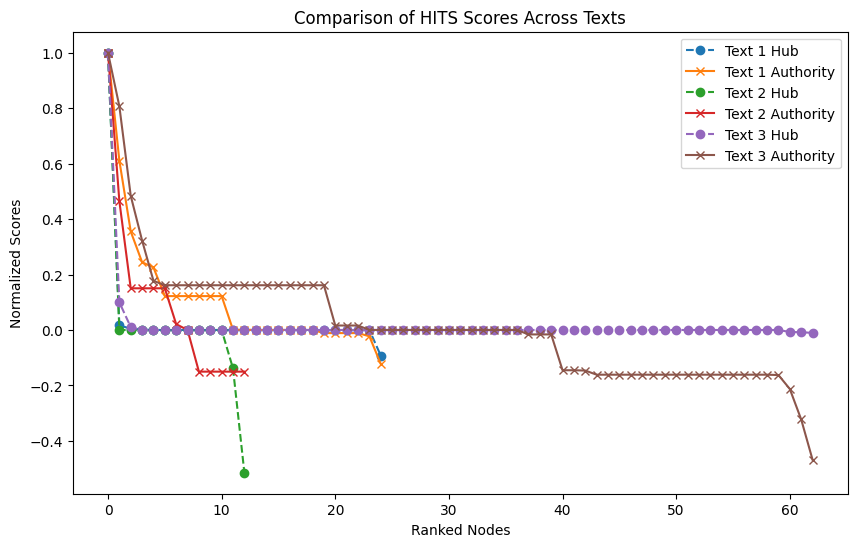

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Example texts represented as graphs (nodes and edges vary)
texts = [
    nx.read_graphml(file_path, node_type=str),  # Text 1
    nx.read_graphml(file_path1, node_type=str),  # Text 2
    nx.read_graphml(file_path2, node_type=str),  # Text 3
]

# Store normalized hub and authority scores for each graph
results = []

for i, G in enumerate(texts):
    # Compute HITS scores
    h, a = nx.hits(G)

    # Normalize scores to [0, 1]
    max_h, max_a = max(h.values(), default=1), max(a.values(), default=1)
    normalized_h = {node: score / max_h for node, score in h.items()}
    normalized_a = {node: score / max_a for node, score in a.items()}

    # Store results
    results.append({"text_id": i + 1, "hub_scores": normalized_h, "authority_scores": normalized_a})

# Compare Results
print("Comparison of Hub and Authority Scores Across Texts:")
for res in results:
    print(f"\nText {res['text_id']}:")
    print("  Hub Scores:", sorted(res['hub_scores'].items(), key=lambda x: x[1], reverse=True))
    print("  Authority Scores:", sorted(res['authority_scores'].items(), key=lambda x: x[1], reverse=True))

# Optional: Visualization
plt.figure(figsize=(10, 6))
for res in results:
    plt.plot(
        sorted(res['hub_scores'].values(), reverse=True),
        label=f"Text {res['text_id']} Hub",
        linestyle="--",
        marker="o",
    )
    plt.plot(
        sorted(res['authority_scores'].values(), reverse=True),
        label=f"Text {res['text_id']} Authority",
        linestyle="-",
        marker="x",
    )
plt.xlabel("Ranked Nodes")
plt.ylabel("Normalized Scores")
plt.title("Comparison of HITS Scores Across Texts")
plt.legend()
plt.show()


In [ ]:
import networkx as nx

# Function to compute single hub/authority score
def compute_deviation_score(scores):
    max_score = max(scores.values())
    deviations = [max_score - score for score in scores.values() if score != max_score]
    return sum(deviations)/len(scores.values())  # Sum of differences

# Calculate deviation scores for each text
results = []

for i, G in enumerate(texts):
    # Compute HITS scores
    h, a = nx.hits(G)

    # Compute single scores
    hub_score = compute_deviation_score(h)
    authority_score = compute_deviation_score(a)

    # Store results
    results.append({
        "text_id": i + 1,
        "hub_score": hub_score,
        "authority_score": authority_score,
    })

# Display results
print("Single Hub and Authority Scores for Each Text:")
for res in results:
    print(f"Text {res['text_id']}: Hub Score = {res['hub_score']:.4f}, Authority Score = {res['authority_score']:.4f}")


Single Hub and Authority Scores for Each Text:
Text 1: Hub Score = 1.0348, Authority Score = 0.2956
Text 2: Hub Score = 2.8111, Authority Score = 0.6722
Text 3: Hub Score = 0.9065, Authority Score = 0.9586


In [ ]:
import networkx as nx

def star_similarity_multidigraph(G):
    # Get the total number of nodes
    num_nodes = len(G.nodes)
    if num_nodes <= 1:
        return 1.0  # A single-node graph is trivially a star

    # Compute in-degree and out-degree
    in_degrees = dict(G.in_degree())
    out_degrees = dict(G.out_degree())

    # Find the node with the highest in-degree and out-degree
    max_in_degree = max(in_degrees.values())
    max_out_degree = max(out_degrees.values())
    print("max_out", max_out_degree)
    print("num nodes", num_nodes)

    # Expected max degree in a star graph
    max_possible_degree = num_nodes - 1

    # Score how close the max degree is to the theoretical max
    in_score = max_in_degree / max_possible_degree
    out_score = max_out_degree / max_possible_degree

    # Verify other nodes have degree of 1
    leaf_in_degrees = [deg for node, deg in in_degrees.items() if deg < max_in_degree]
    leaf_out_degrees = [deg for node, deg in out_degrees.items() if deg < max_out_degree]

    # Check if all other nodes are leaves (degree 1)
    leaf_score_in = sum(1 for deg in leaf_in_degrees if deg == 1) / (num_nodes - 1)
    leaf_score_out = sum(1 for deg in leaf_out_degrees if deg == 1) / (num_nodes - 1)

    # Combine the scores
    return (in_score + out_score + leaf_score_in + leaf_score_out) / 4.0
    return (out_score + leaf_score_out) / 2.0

# Example usage
#G = nx.MultiDiGraph()
#G.add_edges_from([(0, 1), (0, 2), (0, 3), (0, 4)])  # Star-like MultiDiGraph
print(star_similarity_multidigraph(G))  # Output: Similarity score (1.0 for perfect star)


max_out 59
num nodes 37
0.6666666666666667


In [ ]:
file_path = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/evaluative_network_with_oppositions_graphml_20241031/Mann_Beim_Propheten_clean.txt_evaluative_network_with_oppositions.graphml.xml'

In [ ]:
G= nx.read_graphml(file_path, node_type=str)

# Reziprozität

In [ ]:
nx.reciprocity(G, nodes=None)

0.0

In [ ]:
nx.is_directed_acyclic_graph(G)

False

In [ ]:
from networkx.algorithms.community import greedy_modularity_communities
greedy_modularity_communities(G)

[frozenset({'Autor',
            'Der «Versuch»',
            'Ein Mensch',
            'Müller',
            'Müllers',
            'Pucher',
            'deiner seriösen Kluft',
            'der Lärm der Propeller',
            'der Pilot',
            'der Propeller',
            'der unangenehme Teil der Geschichte',
            'die Flugleitung',
            'die gewisse Unordnung',
            'die natürliche Haltung',
            'sein Verhalten von heute morgen',
            'seinen dicken Kopf',
            'solch ein wahnsinniges Gewäsch'}),
 frozenset({'Namenloser Erzähler1',
            'den Niedergang des Theaters',
            'ein unfehlbarer Zankapfel',
            'einem dieser hübschen stählernen Dinger'}),
 frozenset({'blauen Himmel', 'schlechtem Wetter'}),
 frozenset({'Fliegen', 'Flugzeug'})]

In [ ]:
import networkx as nx
from itertools import combinations

def count_120d_triads(graph):
    # Ensure the graph is directed
    if not graph.is_directed():
        raise ValueError("The graph must be directed.")

    # Get all sets of 3 nodes (triads)
    nodes = list(graph.nodes())
    triad_count = 0

    for triad in combinations(nodes, 3):  # Iterate through all possible triads
        subgraph = graph.subgraph(triad)
        edges = set(subgraph.edges())

        # Check if the triad is 120d
        if (
            # One pair has a reciprocal (mutual) link
            (triad[0], triad[1]) in edges and (triad[1], triad[0]) in edges
            # A third node points to one node in the pair or is pointed at
            and (
                (triad[2], triad[0]) in edges or (triad[2], triad[1]) in edges or
                (triad[0], triad[2]) in edges or (triad[1], triad[2]) in edges
            )
        ):
            triad_count += 1

    # Normalize by number of nodes
    normalized_count = triad_count / graph.number_of_nodes()
    return triad_count, normalized_count

# Example usage
# Create a directed graph
G = nx.DiGraph()
G.add_edges_from([
    (1, 2), (2, 1),  # Reciprocal link
    (2, 3), (3, 1)   # Other connections forming a 120d triad
])

# Count 120d triads
triad_count, normalized_count = count_120d_triads(G)
print(f"Total 120d triads: {triad_count}")
print(f"Normalized by number of nodes: {normalized_count}")


Total 120d triads: 1
Normalized by number of nodes: 0.3333333333333333


# Save Screenshots

In [ ]:
# Step 1: Install Playwright and necessary dependencies
!pip install playwright
!python -m playwright install
!apt-get install -y libnss3 libx11-xcb1 libxcomposite1 libxrandr2 libglu1-mesa

# Step 2: Create the PyVis network
#from pyvis.network import Network

# Save the network to an HTML file
nt.write_html('/content/network.html')

# Step 3: Capture the PNG using Playwright
from playwright.async_api import async_playwright

# This code will now work without asyncio.run(), as Colab handles the event loop
async def capture_png():
    async with async_playwright() as p:
        # Launch the browser in headless mode
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()
        page.set_viewport_size({"width": 640, "height": 480})

        # Open the local file (network.html) from Colab environment
        file_path = '/content/network.html'  # Adjust the file path if needed


        await page.goto(f'file://{file_path}')
        await page.wait_for_timeout(2000)

        # Dynamically get the bounding box of the visualization container
        bounding_box = await page.evaluate("""
            () => {
                const container = document.querySelector("#mynetwork");  // PyVis uses this ID
                const rect = container.getBoundingClientRect();
                return {
                    x: rect.left,
                    y: rect.top,
                    width: rect.width,
                    height: rect.height
                };
            }
        """)

        # Take a screenshot of only the visualization container
        await page.screenshot(
            path='/content/network_cropped.png',
            clip={
                "x": bounding_box['x'],
                "y": bounding_box['y'],
                "width": bounding_box['width'],
                "height": bounding_box['height']
            }
        )

        # Close the browser
        await browser.close()

# Run the async function directly in Colab without asyncio.run()
await capture_png()

# Step 4: Download the PNG screenshot to your local machine
from google.colab import files
files.download('/content/network_high_res.png')


Playwright Host validation warning: 
╔══════════════════════════════════════════════════════╗
║ Host system is missing dependencies to run browsers. ║
║ Missing libraries:                                   ║
║     libwoff2dec.so.1.0.2                             ║
║     libgstgl-1.0.so.0                                ║
║     libgstcodecparsers-1.0.so.0                      ║
║     libavif.so.13                                    ║
║     libharfbuzz-icu.so.0                             ║
║     libenchant-2.so.2                                ║
║     libsecret-1.so.0                                 ║
║     libhyphen.so.0                                   ║
║     libmanette-0.2.so.0                              ║
╚══════════════════════════════════════════════════════╝
    at validateDependenciesLinux (/usr/local/lib/python3.10/dist-packages/playwright/driver/package/lib/server/registry/dependencies.js:216:9)
    at async Registry._validateHostRequirements (/usr/local/lib/python3.10/dist

<ipython-input-93-e201b82afe78>:21: RuntimeWarning: coroutine 'Page.set_viewport_size' was never awaited
  page.set_viewport_size({"width": 640, "height": 480})


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import zipfile
from playwright.async_api import async_playwright


# This function captures the PNG from an HTML file
async def capture_png(html_path, png_path):
    async with async_playwright() as p:
        # Launch the browser in headless mode
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()

        # Open the local file (html_path)
        await page.goto(f'file://{html_path}')
        await page.wait_for_timeout(2000)

        # Dynamically get the bounding box of the visualization container
        bounding_box = await page.evaluate("""
            () => {
                const container = document.querySelector("#mynetwork");  // PyVis uses this ID
                const rect = container.getBoundingClientRect();
                return {
                    x: rect.left,
                    y: rect.top,
                    width: rect.width,
                    height: rect.height
                };
            }
        """)

        # Take a screenshot of only the visualization container
        await page.screenshot(
            path=png_path,
            clip={
                "x": bounding_box['x'],
                "y": bounding_box['y'],
                "width": bounding_box['width'],
                "height": bounding_box['height']
            }
        )

        # Close the browser
        await browser.close()


# This function converts all HTML files in the directory to PNGs
async def html_to_png(directory, output_zip):
    """
    Converts all .html files in a specified directory to .png files with the same base name.

    Args:
        directory (str): Path to the directory containing HTML files.
    """
    # Ensure the directory exists
    if not os.path.isdir(directory):
        print("Invalid directory path.")
        return

    # Create a directory to store PNGs
    png_output_dir = os.path.join(directory, "png_output")
    os.makedirs(png_output_dir, exist_ok=True)

    # Iterate through all files in the directory
    for file_name in os.listdir(directory):
        if file_name.endswith('.html'):
            html_path = os.path.join(directory, file_name)
            png_name = os.path.splitext(file_name)[0] + '.png'
            png_path = os.path.join(png_output_dir, png_name)

            print(f"Processing {file_name} -> {png_name}")

            try:
                # Capture the PNG using Playwright
                await capture_png(html_path, png_path)
            except Exception as e:
                print(f"Failed to convert {file_name}: {e}")

    # Create a ZIP file containing all PNGs
    with zipfile.ZipFile(output_zip, "w") as zipf:
        for root, _, files in os.walk(png_output_dir):
            for file in files:
                zipf.write(os.path.join(root, file),
                           arcname=os.path.relpath(os.path.join(root, file), png_output_dir))

    print(f"PNG files have been zipped into: {output_zip}")


# Provide the path to your directory with HTML files and the output ZIP file
directory_path = r"/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/evaluative_network_with_oppositions_20241027"
zip_file_path = r"/content/drive/My Drive/output_images.zip"

# Run the async function directly, without asyncio.run()
await html_to_png(directory_path, zip_file_path)


Processing Bachmann_Arkadien_clean.txt_evaluative_network_with_oppositions.html -> Bachmann_Arkadien_clean.txt_evaluative_network_with_oppositions.png
Processing Auerbach_Der_Kindesmord.txt_evaluative_network_with_oppositions.html -> Auerbach_Der_Kindesmord.txt_evaluative_network_with_oppositions.png
Processing Böll_Wanderer_kommst_du_nach_Spa_clean.txt_evaluative_network_with_oppositions.html -> Böll_Wanderer_kommst_du_nach_Spa_clean.txt_evaluative_network_with_oppositions.png
Processing Brecht_Müllers_natürliche_Haltung.txt_evaluative_network_with_oppositions.html -> Brecht_Müllers_natürliche_Haltung.txt_evaluative_network_with_oppositions.png
Processing Brecht_Herr_Keuner_und_die_Schauspielerin.txt_evaluative_network_with_oppositions.html -> Brecht_Herr_Keuner_und_die_Schauspielerin.txt_evaluative_network_with_oppositions.png
Processing Grimm_Aschenputtel_clean.txt_evaluative_network_with_oppositions.html -> Grimm_Aschenputtel_clean.txt_evaluative_network_with_oppositions.png


In [ ]:
import os
import zipfile
from playwright.async_api import async_playwright

# This function captures the JPEG from an HTML file
async def capture_jpg(html_path, jpg_path):
    async with async_playwright() as p:
        # Launch the browser in headless mode
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()
        #await page.set_viewport_size({"width": 6000, "height": 4000})
        # Emulate high-DPI
        context = await browser.new_context(
          viewport={ 'width': 2560, 'height': 1440 },
          device_scale_factor=2,
        )

        # Open the local file (html_path)
        await page.goto(f'file://{html_path}')

        # Wait for the visualization container to be available
        await page.wait_for_selector("#mynetwork", timeout=5000)  # 5 seconds

        # Dynamically get the bounding box of the visualization container
        bounding_box = await page.evaluate("""
            () => {
                const container = document.querySelector("#mynetwork");
                const rect = container.getBoundingClientRect();
                return {
                    x: rect.left,
                    y: rect.top,
                    width: rect.width,
                    height: rect.height
                };
            }
        """)

        if bounding_box['width'] > 0 and bounding_box['height'] > 0:
            # Capture the screenshot as a high-quality JPEG


            await page.screenshot(
                path=jpg_path,
                type="jpeg",  # Specify JPEG type
                quality=100,  # High quality (0-100)
                clip={
                    "x": bounding_box['x'],
                    "y": bounding_box['y'],
                    "width": bounding_box['width'],
                    "height": bounding_box['height']
                }
            )
            print(f"Captured screenshot: {html_path} -> {jpg_path}")
        else:
            print(f"Bounding box is empty for {html_path}, skipping screenshot.")

        # Close the browser
        await browser.close()

# This function converts all HTML files in the directory to high-resolution JPGs
async def html_to_jpg(directory, output_zip):
    """
    Converts all .html files in a specified directory to .jpg files with the same base name.
    """
    # Ensure the directory exists
    if not os.path.isdir(directory):
        print("Invalid directory path.")
        return

    # Create a directory to store JPGs
    jpg_output_dir = os.path.join(directory, "jpg_output")
    os.makedirs(jpg_output_dir, exist_ok=True)

    # Iterate through all files in the directory
    for file_name in os.listdir(directory)[:2]:
        if file_name.endswith('.html'):
            html_path = os.path.join(directory, file_name)
            jpg_name = os.path.splitext(file_name)[0] + '.jpg'
            jpg_path = os.path.join(jpg_output_dir, jpg_name)

            print(f"Processing {file_name} -> {jpg_name}")

            try:
                # Capture the high-resolution JPG using Playwright
                await capture_jpg(html_path, jpg_path)
            except Exception as e:
                print(f"Failed to convert {file_name}: {e}")

    # Create a ZIP file containing all JPGs
    with zipfile.ZipFile(output_zip, "w") as zipf:
        for root, _, files in os.walk(jpg_output_dir):
            for file in files:
                zipf.write(os.path.join(root, file),
                           arcname=os.path.relpath(os.path.join(root, file), jpg_output_dir))

    print(f"JPG files have been zipped into: {output_zip}")

# Provide the path to your directory with HTML files and the output ZIP file
directory_path = r"/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/evaluative_network_with_oppositions_20241027"
zip_file_path = r"/content/drive/My Drive/output_images.zip"

# Run the async function directly, without asyncio.run()
await html_to_jpg(directory_path, zip_file_path)


Processing Bachmann_Arkadien_clean.txt_evaluative_network_with_oppositions.html -> Bachmann_Arkadien_clean.txt_evaluative_network_with_oppositions.jpg
Captured screenshot: /content/drive/My Drive/Kulturkritik/Annotation_Auswertung/evaluative_network_with_oppositions_20241027/Bachmann_Arkadien_clean.txt_evaluative_network_with_oppositions.html -> /content/drive/My Drive/Kulturkritik/Annotation_Auswertung/evaluative_network_with_oppositions_20241027/jpg_output/Bachmann_Arkadien_clean.txt_evaluative_network_with_oppositions.jpg
Processing Auerbach_Der_Kindesmord.txt_evaluative_network_with_oppositions.html -> Auerbach_Der_Kindesmord.txt_evaluative_network_with_oppositions.jpg
Captured screenshot: /content/drive/My Drive/Kulturkritik/Annotation_Auswertung/evaluative_network_with_oppositions_20241027/Auerbach_Der_Kindesmord.txt_evaluative_network_with_oppositions.html -> /content/drive/My Drive/Kulturkritik/Annotation_Auswertung/evaluative_network_with_oppositions_20241027/jpg_output/Auerba